# **Predicting Smartphone Addiction among Teenagers**

***Data description:***
The dataset contains 25 features across 4 categories:

**Demographic Information:**
- `ID` — Unique identifier for each student (dropped, not informative)
- `Name` — Student name (dropped, not informative)
- `Age` — Age of the teenager (13–18 years)
- `Gender` — Gender identity (Male, Female, Other)
- `Location` — City/town of residence (dropped, too many unique values)
- `School_Grade` — Academic grade level (7th–12th)

**Phone Usage Behaviour:**
- `Daily_Usage_Hours` — Average daily smartphone usage (hours) — strongest predictor (r=0.61)
- `Weekend_Usage_Hours` — Average weekend smartphone usage (hours)
- `Screen_Time_Before_Bed` — Hours of phone use before sleeping
- `Phone_Checks_Per_Day` — Number of times phone is checked daily
- `Apps_Used_Daily` — Number of unique apps used per day
- `Time_on_Social_Media` — Daily hours spent on social media
- `Time_on_Gaming` — Daily hours spent gaming
- `Time_on_Education` — Daily hours spent on educational content
- `Phone_Usage_Purpose` — Primary purpose of phone use (Browsing, Gaming, Social Media, Education, Communication)

**Health & Wellbeing:**
- `Sleep_Hours` — Average nightly sleep hours
- `Exercise_Hours` — Daily exercise hours
- `Anxiety_Level` — Self-reported anxiety score (0–10)
- `Depression_Level` — Self-reported depression score (0–10)
- `Self_Esteem` — Self-reported self-esteem score (0–10)

**Social & Academic:**
- `Academic_Performance` — Academic score (50–100)
- `Social_Interactions` — Number of daily social interactions (0–10)
- `Parental_Control` — Level of parental phone monitoring (0–10)
- `Family_Communication` — Frequency of family communication (0–10)

**Target Variable:**
- `Addiction_Level` — Continuous score (1–10) measuring smartphone addiction severity


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from datetime import datetime

import warnings 
warnings.filterwarnings('ignore')

In [2]:
phone_usage = pd.read_csv('/Users/tanggiee/Desktop/Data visualization/Test/SmartPhone_Addiction/teen_phone_addiction_dataset.csv')

In [3]:
phone_usage.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [4]:
phone_usage['Age'].unique()

array([13, 17, 18, 14, 16, 19, 15])

## 2. Understand dataset

In [5]:
phone_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [6]:
phone_usage.shape

(3000, 25)

In [7]:
phone_usage.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [8]:
phone_usage.dtypes

ID                          int64
Name                       object
Age                         int64
Gender                     object
Location                   object
School_Grade               object
Daily_Usage_Hours         float64
Sleep_Hours               float64
Academic_Performance        int64
Social_Interactions         int64
Exercise_Hours            float64
Anxiety_Level               int64
Depression_Level            int64
Self_Esteem                 int64
Parental_Control            int64
Screen_Time_Before_Bed    float64
Phone_Checks_Per_Day        int64
Apps_Used_Daily             int64
Time_on_Social_Media      float64
Time_on_Gaming            float64
Time_on_Education         float64
Phone_Usage_Purpose        object
Family_Communication        int64
Weekend_Usage_Hours       float64
Addiction_Level           float64
dtype: object

In [9]:
phone_usage.nunique()

ID                        3000
Name                      2933
Age                          7
Gender                       3
Location                  2726
School_Grade                 6
Daily_Usage_Hours          107
Sleep_Hours                 71
Academic_Performance        51
Social_Interactions         11
Exercise_Hours              39
Anxiety_Level               10
Depression_Level            10
Self_Esteem                 10
Parental_Control             2
Screen_Time_Before_Bed      27
Phone_Checks_Per_Day       131
Apps_Used_Daily             16
Time_on_Social_Media        51
Time_on_Gaming              41
Time_on_Education           31
Phone_Usage_Purpose          5
Family_Communication        10
Weekend_Usage_Hours        120
Addiction_Level             80
dtype: int64

In [10]:
phone_usage.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours',
       'Addiction_Level'],
      dtype='object')

In [11]:
with pd.option_context('display.max_columns', None):
    display(phone_usage.head())

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,0.1,10,3,8,0,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,0.0,3,7,3,0,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,0.8,2,3,10,0,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,1.6,9,10,3,0,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,1.1,1,5,1,0,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


## 3. Data Cleaning


In [12]:
# Check missing values 
phone_usage.isnull().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

In [13]:
# Check duplicates
phone_usage.duplicated().sum()


0

### *3.1. Outliers detection*

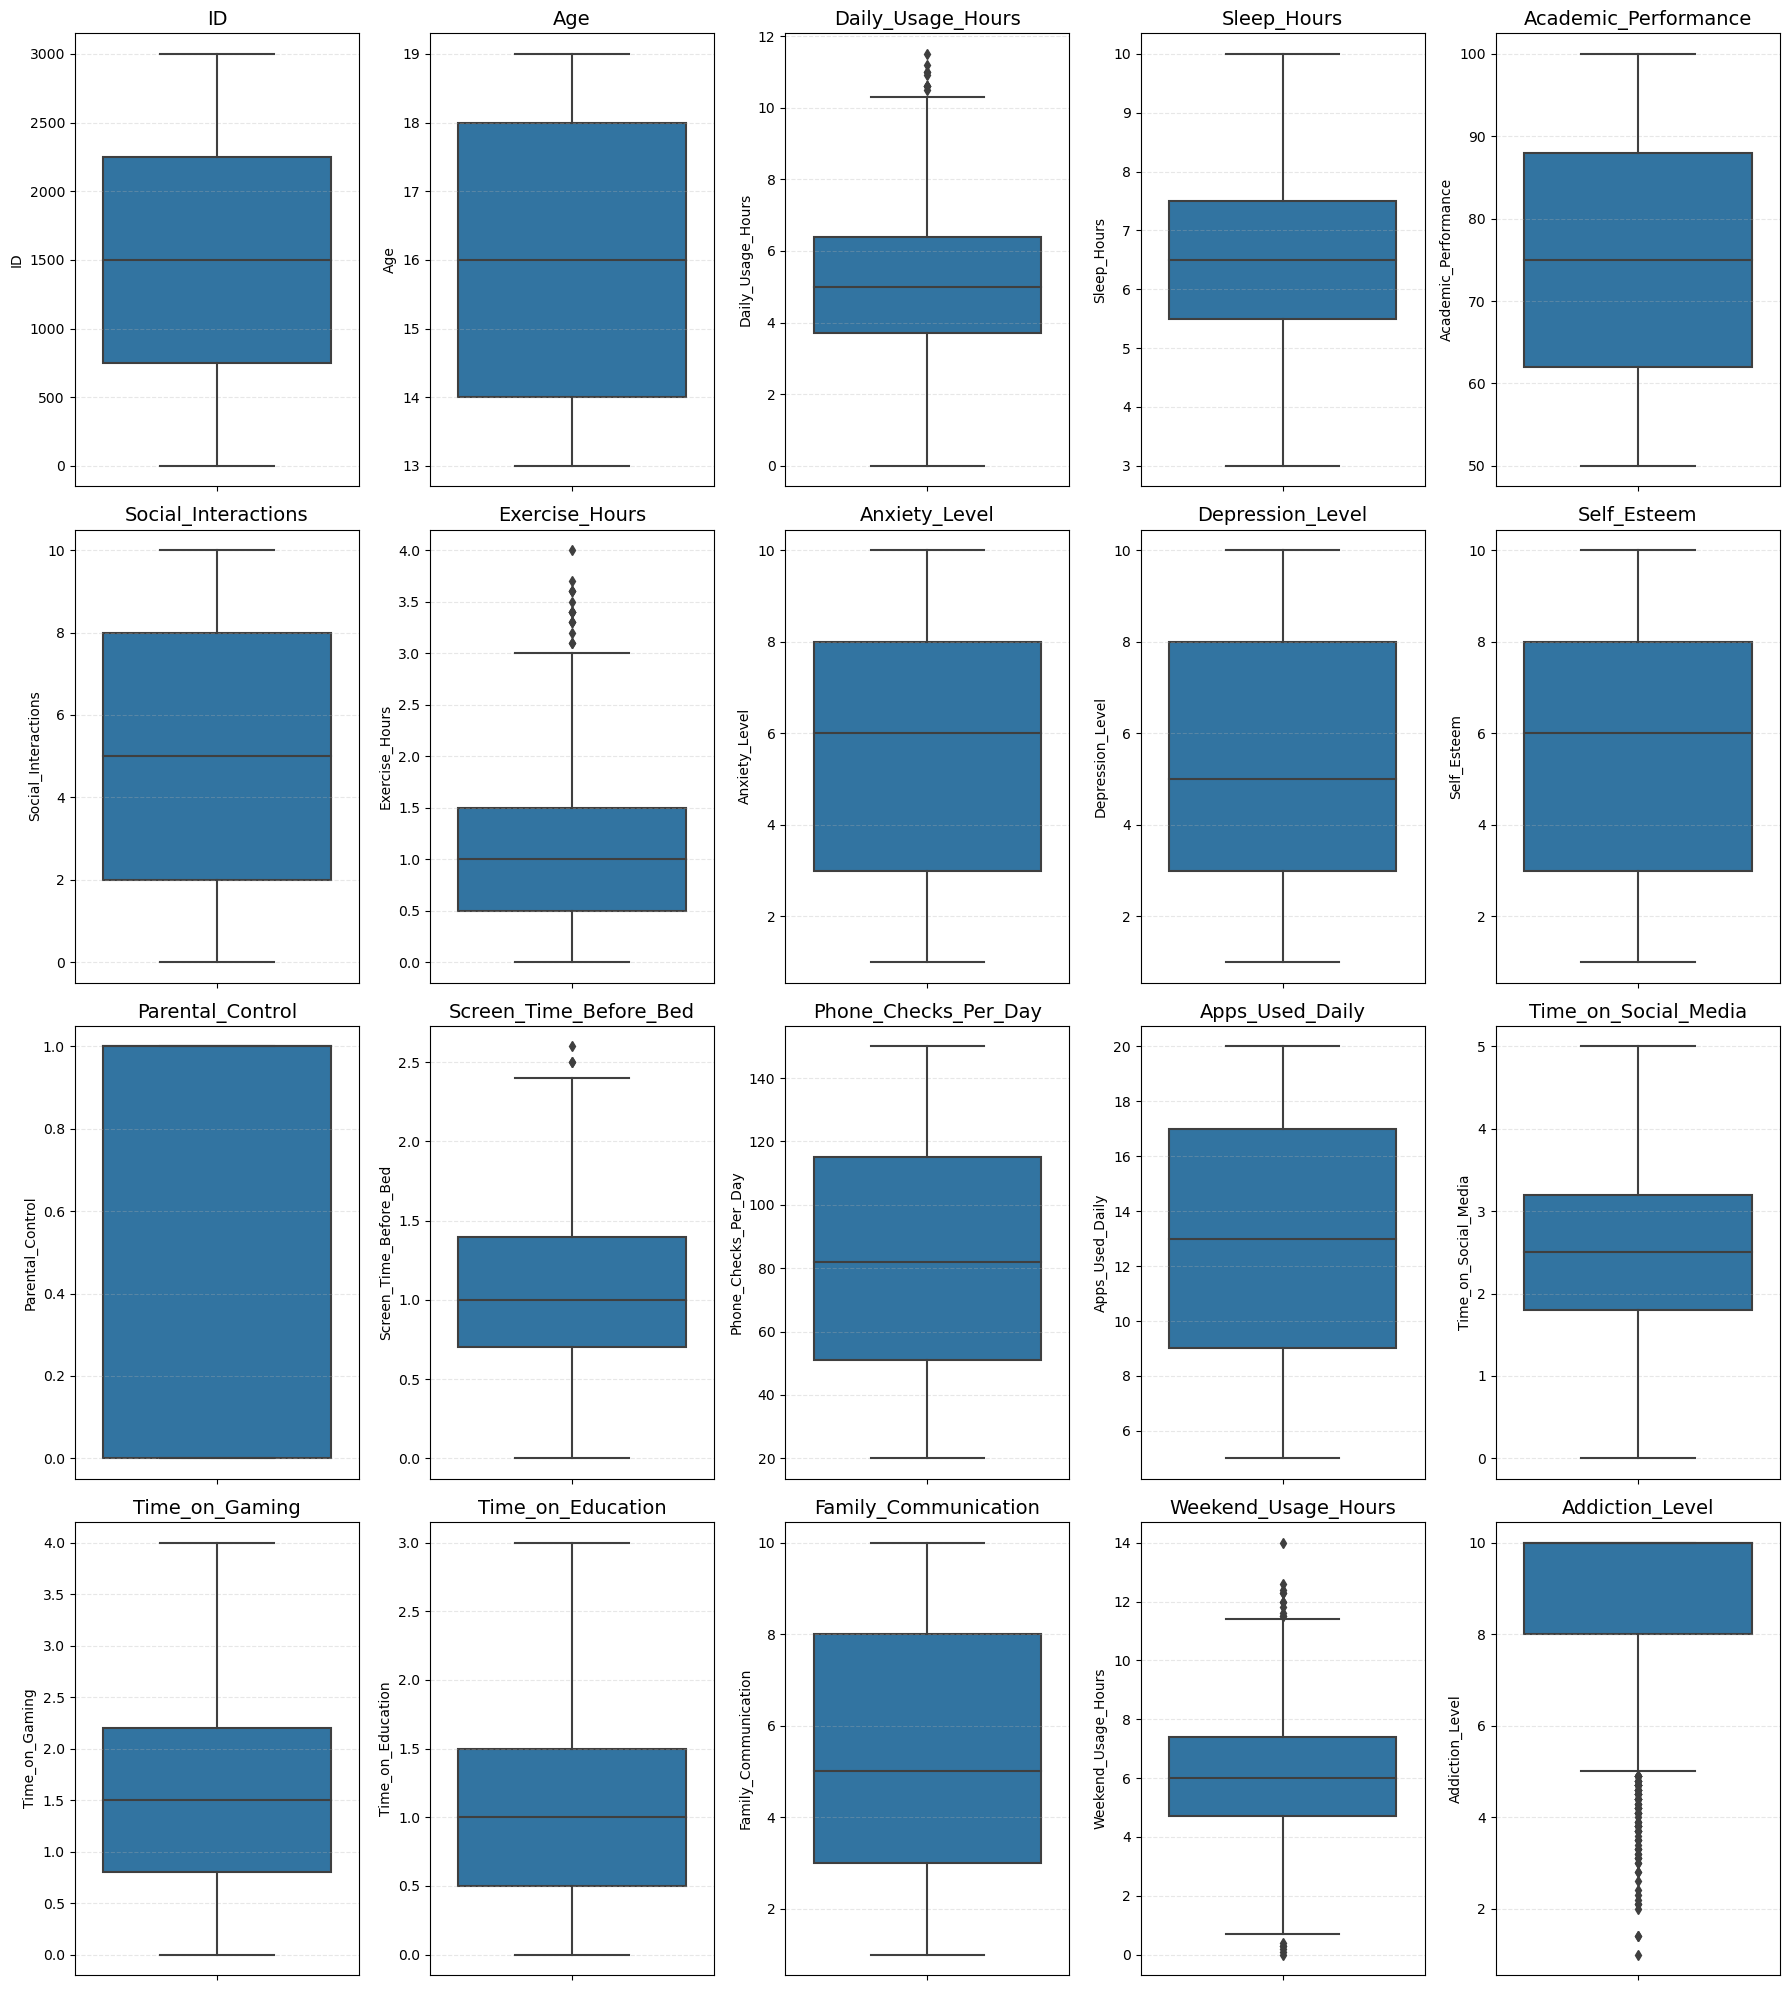

In [14]:
import math
num_cols = phone_usage.select_dtypes(include=['number']).columns.tolist()

# Set up grid
cols = 5
rows = math.ceil(len(num_cols) / cols)
fig, axs = plt.subplots(rows, cols, figsize=(18, 5 * rows), constrained_layout=True)

# 3. Flatten axs so you can iterate easily, even with multiple rows
for ax, col in zip(axs.flat, num_cols):
    sns.boxplot(y=phone_usage[col], ax=ax)
    ax.set_title(col, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# count number of outliers 
# Calculate IQR for all numerical columns at once
Q1 = phone_usage[num_cols].quantile(0.25)
Q3 = phone_usage[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries (1.5 * IQR rule)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count values that fall outside these bounds
outliers_count = ((phone_usage[num_cols] < lower_bound) | (phone_usage[num_cols] > upper_bound)).sum()

print("___Outlier counts per feature___")
print(outliers_count.sort_values(ascending=False))

___Outlier counts per feature___
Addiction_Level           96
Weekend_Usage_Hours       17
Exercise_Hours            17
Daily_Usage_Hours         10
Screen_Time_Before_Bed     3
Family_Communication       0
Time_on_Education          0
Time_on_Gaming             0
Time_on_Social_Media       0
Apps_Used_Daily            0
Phone_Checks_Per_Day       0
ID                         0
Age                        0
Self_Esteem                0
Depression_Level           0
Anxiety_Level              0
Social_Interactions        0
Academic_Performance       0
Sleep_Hours                0
Parental_Control           0
dtype: int64


In [16]:
# Remove outliers but keep the 'Addiction_Level' column the same 
target_cols = ['Weekend_Usage_Hours', 'Exercise_Hours', 'Daily_Usage_Hours', 'Screen_Time_Before_Bed']

# Remove rows with outliers
phone_usage = phone_usage[~((phone_usage[target_cols] < lower_bound) | 
                           (phone_usage[target_cols] > upper_bound)).any(axis=1)]

In [17]:
phone_usage.shape

(2953, 25)

## 4. EDA/Data visualization






In [18]:
print (plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', 'BuGn_r', 'BuPu_r', 'CMRmap_r', 'GnBu_r', 'G

In [19]:
# check the unique value of categorical columns 
cat_cols = ['Name', 'Gender', 'Location', 
            'School_Grade', 'Phone_Usage_Purpose']

for col in cat_cols:
    print(f"Unique values in {col}:", phone_usage[col].unique())

Unique values in Name: ['Shannon Francis' 'Scott Rodriguez' 'Adrian Knox' ... 'Norman Hughes'
 'Barbara Hinton' 'Curtis Johnson']
Unique values in Gender: ['Female' 'Other' 'Male']
Unique values in Location: ['Hansonfort' 'Theodorefort' 'Lindseystad' ... 'Rebeccaton' 'Ramirezmouth'
 'Lake Alexander']
Unique values in School_Grade: ['9th' '7th' '11th' '12th' '10th' '8th']
Unique values in Phone_Usage_Purpose: ['Browsing' 'Education' 'Social Media' 'Gaming' 'Other']


In [20]:
# check number of unique values of categorical columns 
for col in cat_cols:
    print(f"Number of unique values in {col}:", phone_usage[col].nunique())

Number of unique values in Name: 2889
Number of unique values in Gender: 3
Number of unique values in Location: 2687
Number of unique values in School_Grade: 6
Number of unique values in Phone_Usage_Purpose: 5


In [21]:
# drop columns 'Name' & 'Location' since no. unique values ~ no. of rows 
# which create visual noise & high cardinality (~2,726 unique values for 3,000 rows)
cat_cols.remove('Name')
cat_cols.remove('Location')

<Figure size 1500x1000 with 0 Axes>

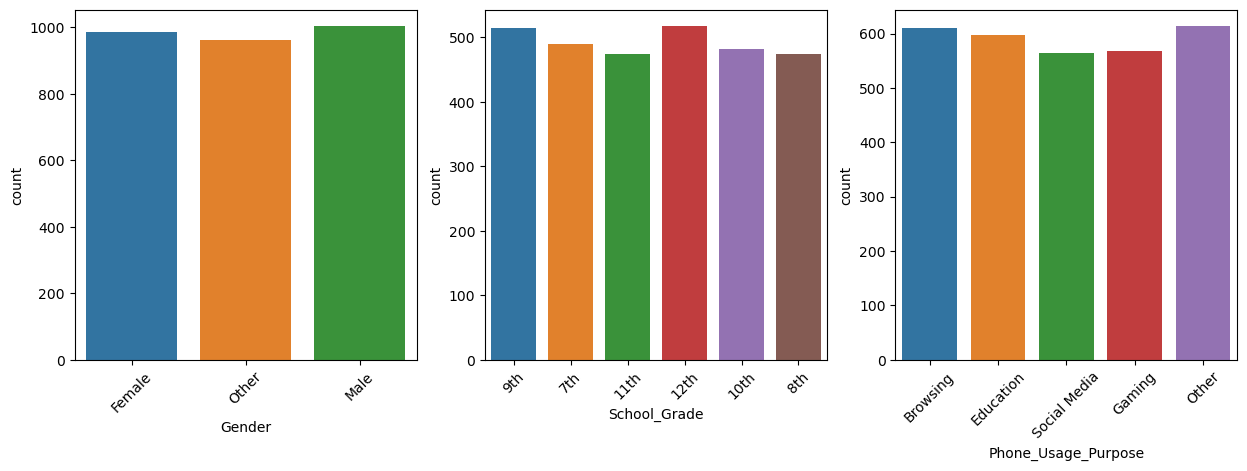

In [22]:
# see the distribution of categorical columns 
plt.figure(figsize=(15, 10))

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=phone_usage, x=col)
    plt.xticks(rotation=45)

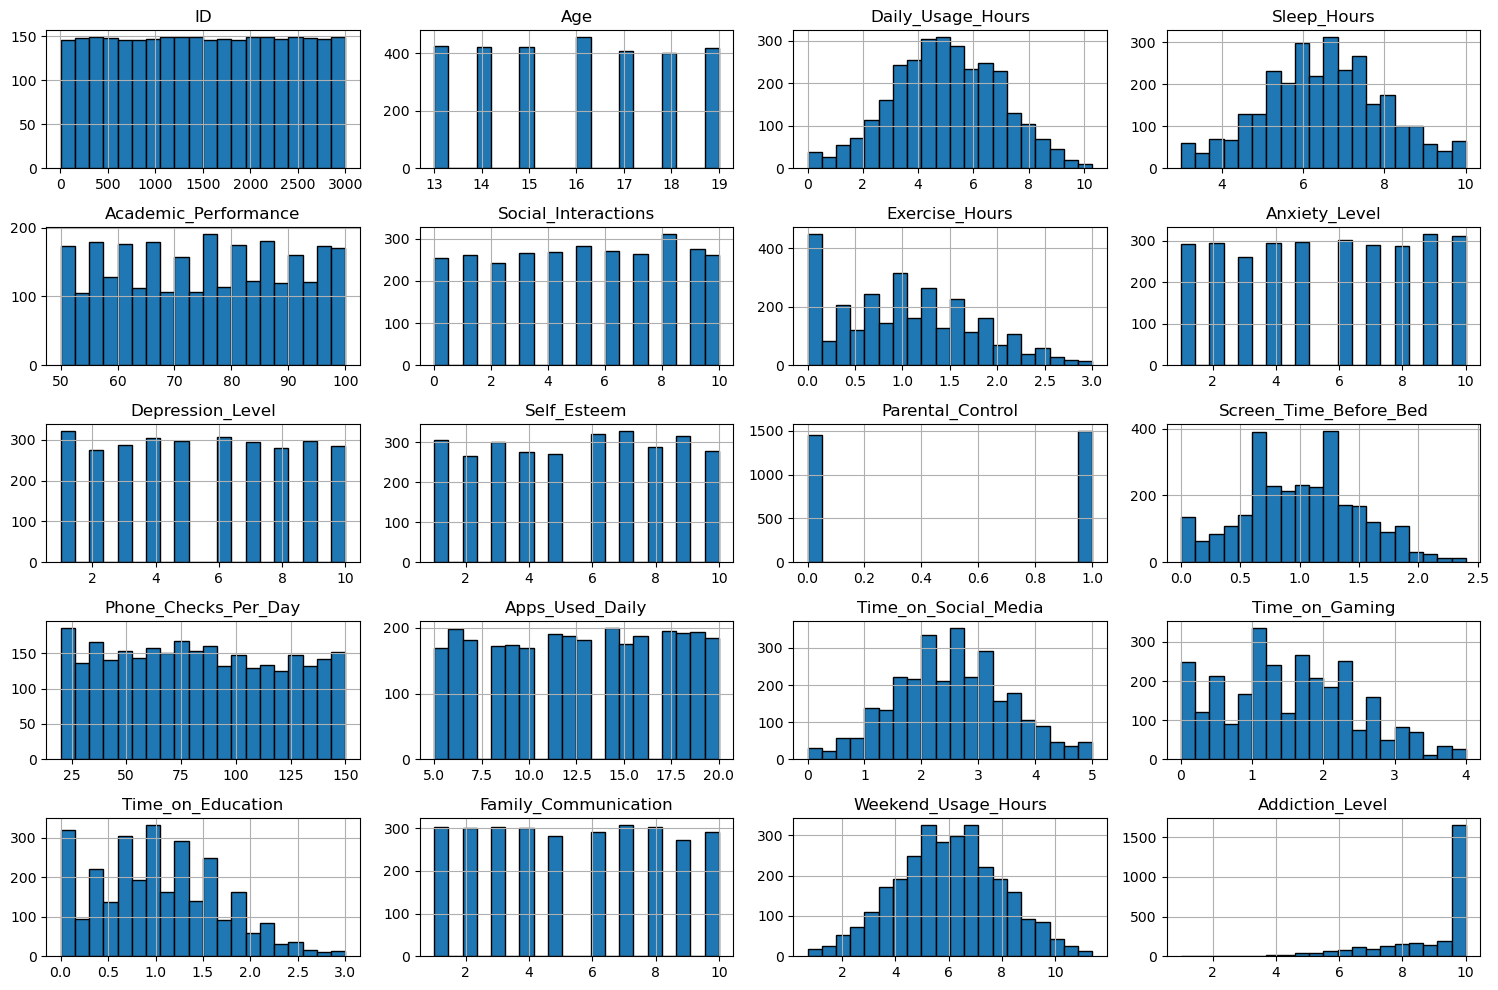

In [23]:
# see the distribution of the data 
# Creates a grid of histograms for all numerical columns
phone_usage.hist(bins=20, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()


- columns that follow normal distribution: *'Daily_Usage_Hours', 'Sleep_Hours', 'Screen_Time_Before_Bed', 'Time_on_Social_Media', 'Time_on_Gaming', 'Weekend_Usage_Hours'*
- *'Addiction_Level'* is heavily skewed. We have a target imblance 
- *'Exercise_Hours'* and *'Time_on_Education'* & *'Time_on_Gaming'* are right-skewed (most values at the low end).
- Mental health metrics appear uniform (flat)




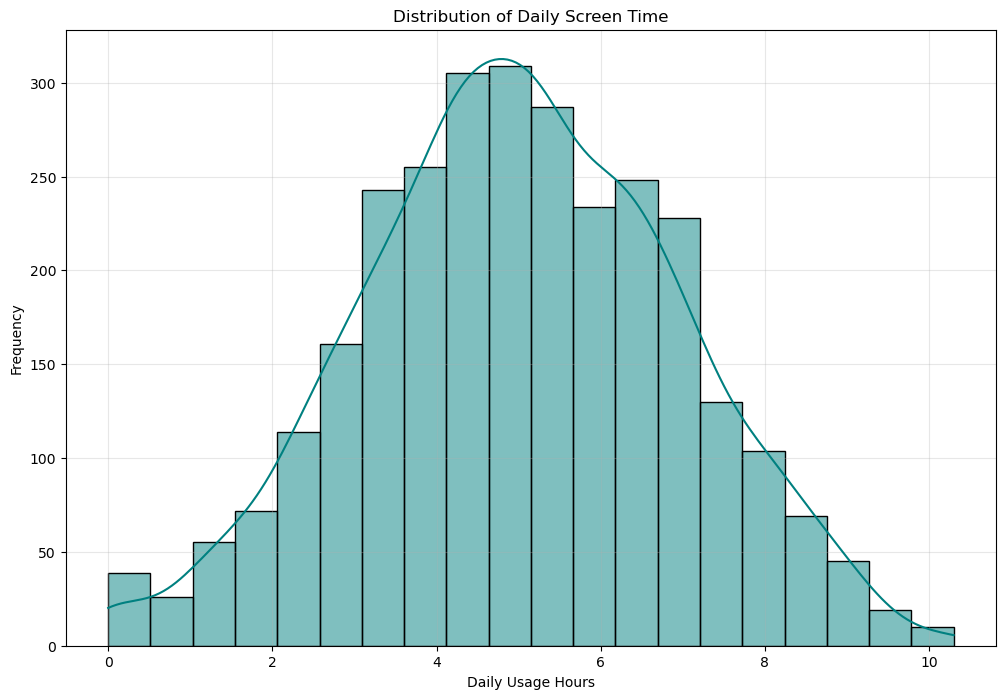

In [24]:
# distribution of daily usage hours
plt.figure(figsize = (12,8))
sns.histplot(phone_usage['Daily_Usage_Hours'], kde=True, bins=20, color='teal')

plt.title('Distribution of Daily Screen Time')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Frequency')
plt.grid(True, alpha = 0.3)
plt.show()


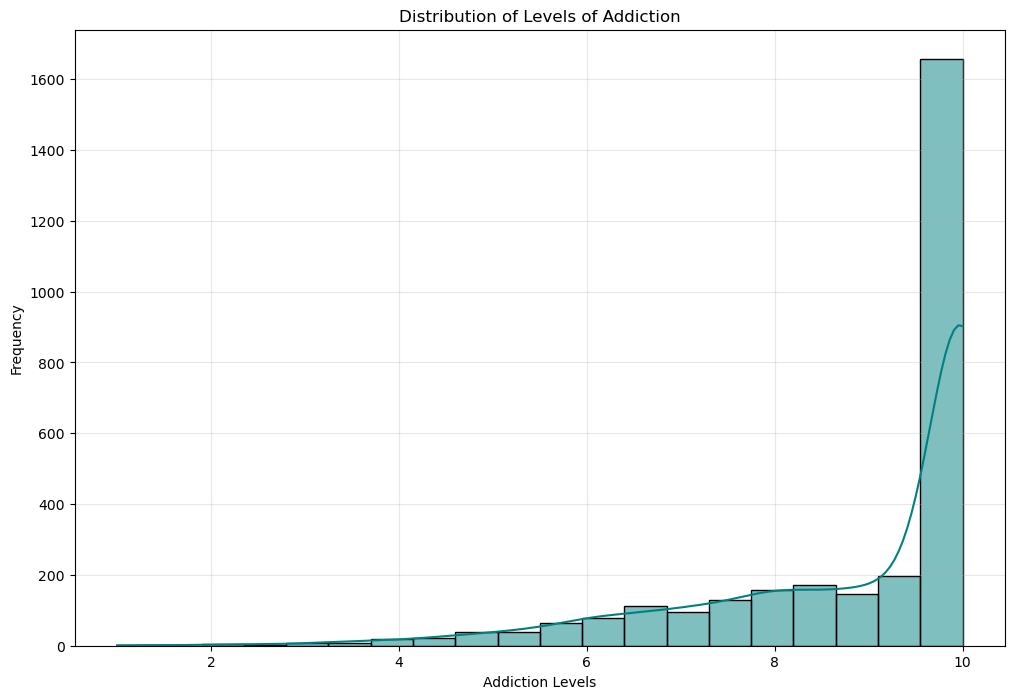

In [25]:
# distribution of Labels/Addiction_Level 
plt.figure(figsize = (12,8))
sns.histplot(phone_usage['Addiction_Level'], kde=True, bins=20, color='teal')

plt.title('Distribution of Levels of Addiction')
plt.xlabel('Addiction Levels')
plt.ylabel('Frequency')
plt.grid(True, alpha = 0.3)
plt.show()



### **3.1. Demographics** 

**a. Age**

Hypothesis 1: Use increases significantly with age. With the highest times reported for people less than 20 years old, principally adolescents, approximately 14 years old. This fact is related to the decreased self-control found in this age group

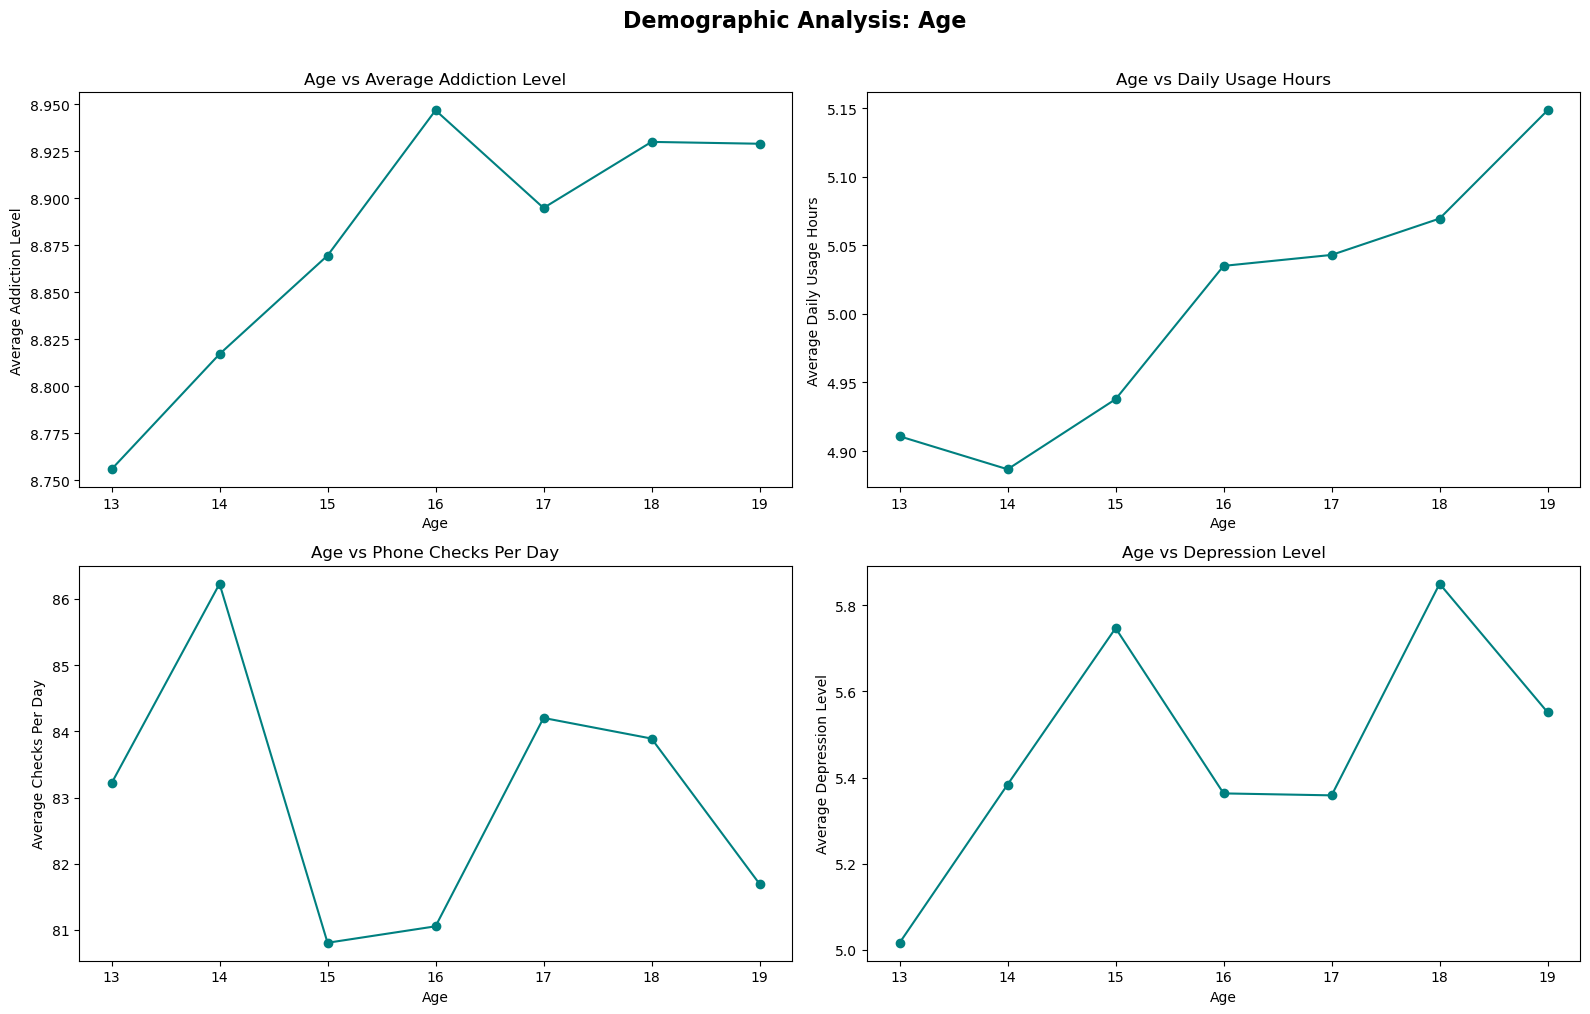

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10)) #2D array shape
axes = axes.flatten() #Converts the 2D array into a flat 1D list: [ax1, ax2, ax3, ax4]

# Chart 1: Age vs Addiction Level
age_addiction = phone_usage.groupby(by='Age', observed=True)['Addiction_Level'].mean().reset_index() # Without reset_index — Age becomes the index, not a column
axes[0].plot(age_addiction['Age'], age_addiction['Addiction_Level'], marker='o', color='teal')
axes[0].set_title('Age vs Average Addiction Level')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Average Addiction Level')

# Chart 2: Age vs Daily Usage Hours
age_usage = phone_usage.groupby(by='Age')['Daily_Usage_Hours'].mean().reset_index()
axes[1].plot(age_usage['Age'], age_usage['Daily_Usage_Hours'], marker='o', color='teal')
axes[1].set_title('Age vs Daily Usage Hours')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Average Daily Usage Hours')

# Chart 3: Age vs Phone Checks Per Day
age_checks = phone_usage.groupby(by='Age')['Phone_Checks_Per_Day'].mean().reset_index()
axes[2].plot(age_checks['Age'], age_checks['Phone_Checks_Per_Day'], marker='o', color='teal')
axes[2].set_title('Age vs Phone Checks Per Day')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Average Checks Per Day')

# Chart 4: Age vs Depression Level
age_depression = phone_usage.groupby(by='Age')['Depression_Level'].mean().reset_index()
axes[3].plot(age_depression['Age'], age_depression['Depression_Level'], marker='o', color='teal')
axes[3].set_title('Age vs Depression Level')
axes[3].set_xlabel('Age')
axes[3].set_ylabel('Average Depression Level')

plt.suptitle('Demographic Analysis: Age', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observation**: Age has minimal influence across all four metrics. While there is a slight upward trend peaking at 16 (chart 1), it does not really reflect the hypothesis. Age alone is a poor predictor of addiction level within the teenage population.

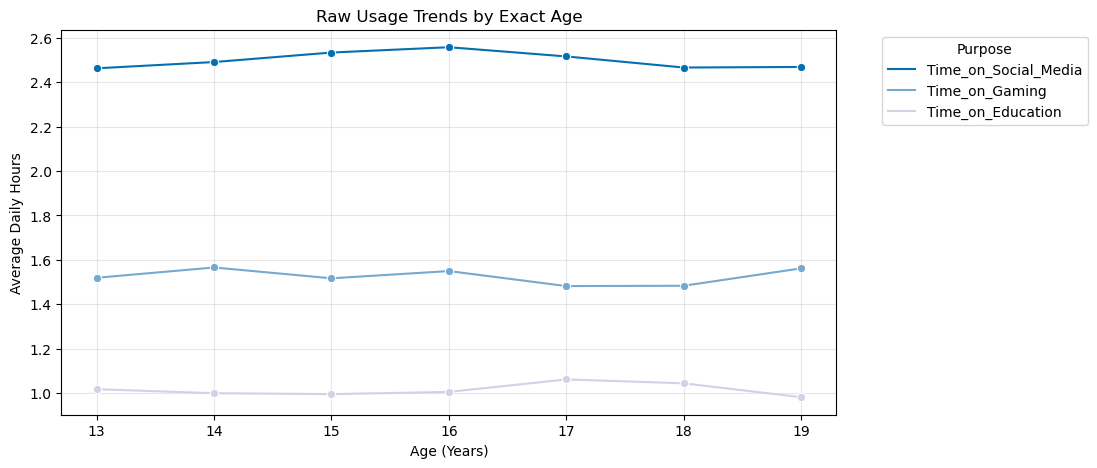

In [27]:
# Group by the exact Age and calculate means for your categories
time = ['Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education']
age_raw_usage = phone_usage.groupby('Age', observed=True)[time].mean().reset_index()

# Melt for Seaborn compatibility
age_raw_melted = age_raw_usage.melt(id_vars='Age', var_name='Purpose', value_name='Hours')

# Plotting 
plt.figure(figsize=(10,5))

sns.lineplot(data=age_raw_melted, x='Age', y='Hours', hue='Purpose', marker='o', palette='PuBu_r')

plt.title('Raw Usage Trends by Exact Age')
plt.ylabel('Average Daily Hours')
plt.xlabel('Age (Years)')
plt.xticks(age_raw_usage['Age']) # Ensure every age year is labeled on the x-axis
plt.grid(True, alpha = 0.3)
plt.legend(title="Purpose", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**b. Gender**

Hypothesis 2: Problematic use is higher in girls/females than in boys; females show higher levels of dependence, typically related to sociability and interpersonal relationships.

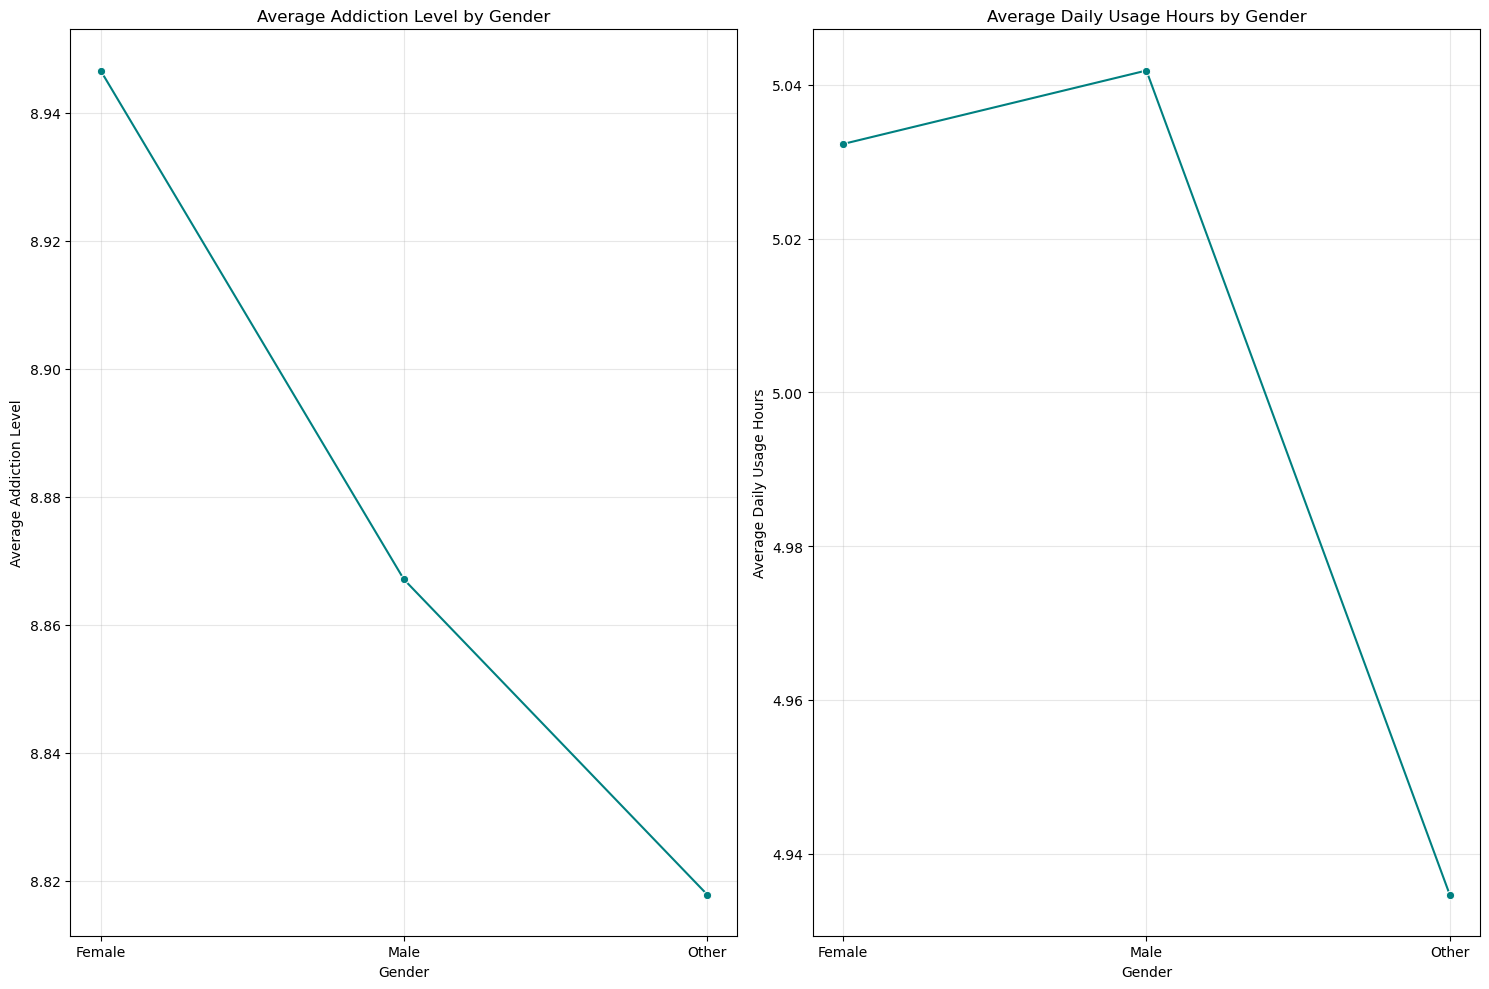

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# First plot: Relationship between Gender and Addiction Level 
gender_addiction = phone_usage.groupby(by='Gender')['Addiction_Level'].mean().reset_index()
sns.lineplot(data=gender_addiction, x='Gender', y='Addiction_Level', marker='o', color='teal', ax=axes[0])
axes[0].set_title('Average Addiction Level by Gender')
axes[0].set_ylabel('Average Addiction Level')
axes[0].grid(True, alpha=0.3)

# Second plot: Which genders have peak usage times? 
usage_gender = phone_usage.groupby(by='Gender')['Daily_Usage_Hours'].mean().reset_index()
sns.lineplot(data=usage_gender, x='Gender', y='Daily_Usage_Hours', marker='o', color='teal', ax=axes[1])
axes[1].set_title('Average Daily Usage Hours by Gender')
axes[1].set_ylabel('Average Daily Usage Hours')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation**: Gender differences are negligible. Despite Males using their phones more daily, Females score higher on addiction, suggesting that how you use your phone matters more than how long. 

--> Gender is not a meaningful predictor of addiction level in this dataset.

**c. Education**

Hypothesis 3: There is a direct relationship between education level and problematic use, which they attributed to the time spent away from home and the isolation caused by extended periods of study.


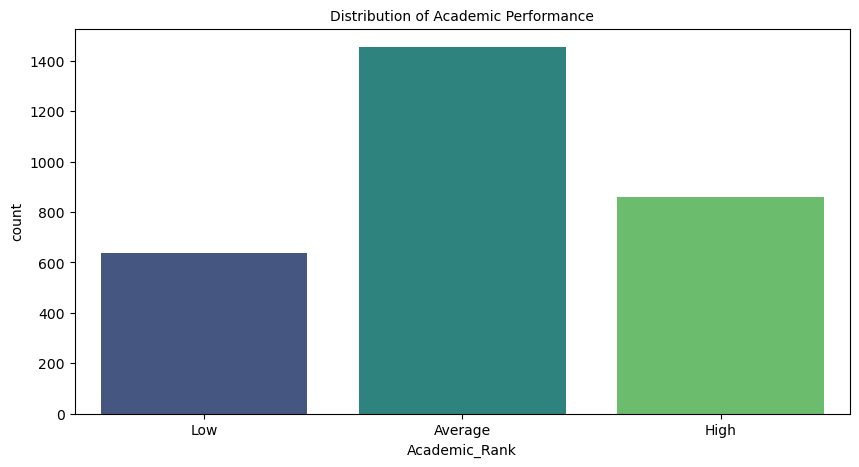

In [29]:
# Group into different performance level to see this trend better
# 0-60: Low, 60-85: Average, 85-100: High
bins = [0, 60, 85, 100]
labels = ['Low', 'Average', 'High']

plot_df = phone_usage.copy() # make a copy to keep your original dataset clean

plot_df['Academic_Rank'] = pd.cut(plot_df['Academic_Performance'], bins=bins, labels=labels)

plt.figure(figsize=(10, 5))
sns.countplot(data=plot_df, x='Academic_Rank', palette='viridis', order=['Low', 'Average', 'High'])
plt.title('Distribution of Academic Performance', fontsize=10)
plt.show()

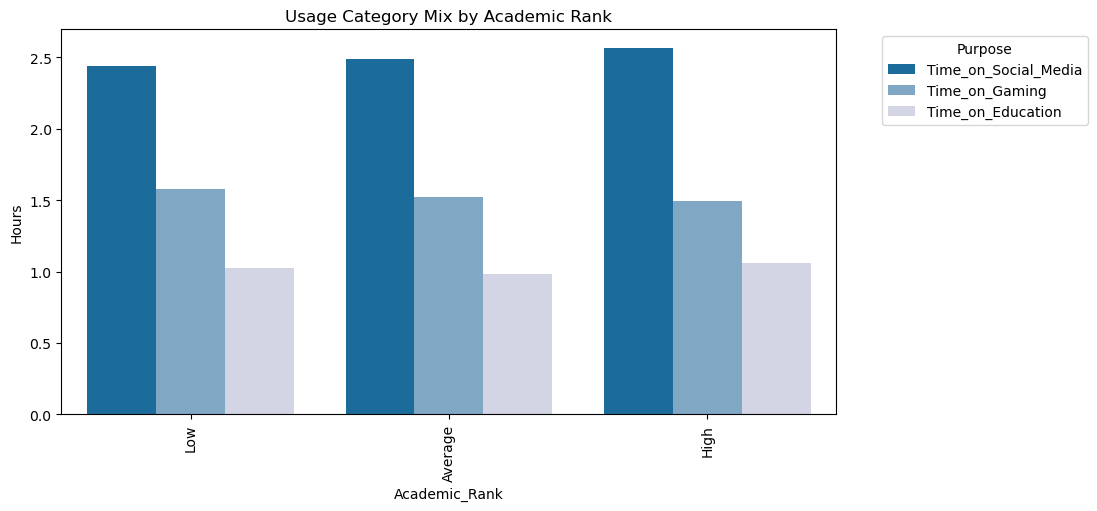

In [30]:
# Do teens with high academic performance use their phones differently (purpose, timing, or category mix)?
time = ['Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education']
academic_time = plot_df.groupby('Academic_Rank', observed=True)[time].mean()

#Melt the data to make it compatible with the sns.barplot(x, y, hue) style
academic_mix = plot_df.groupby('Academic_Rank', observed=True)[time].mean().reset_index()
academic_melted = academic_mix.melt(id_vars='Academic_Rank', var_name='Purpose', value_name='Hours')

plt.figure(figsize=(10,5))

sns.barplot(
    x = 'Academic_Rank', 
    y = 'Hours', 
    hue = 'Purpose', 
    data = academic_melted, 
    palette = 'PuBu_r', 
    order = ['Low', 'Average', 'High'] # Using your specific label order
    )

plt.xticks(size = 10, rotation = 90)
plt.title('Usage Category Mix by Academic Rank')
plt.legend(title="Purpose", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

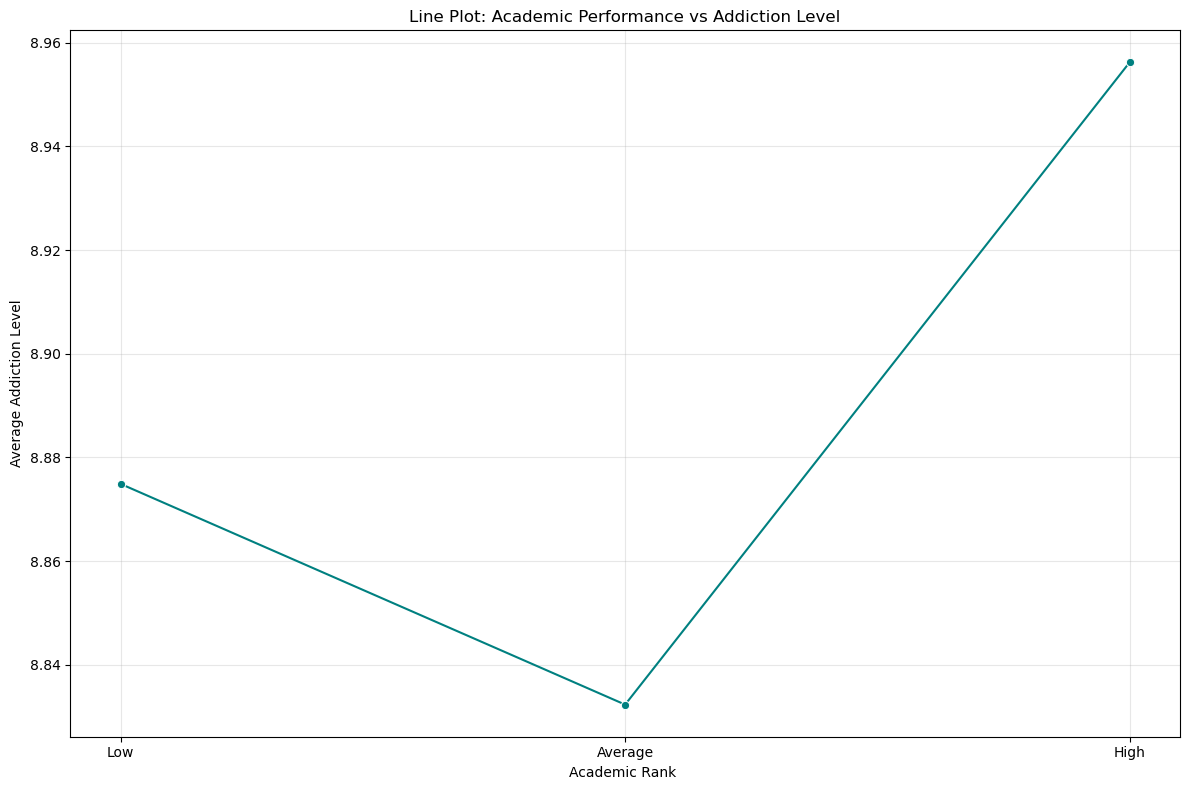

In [31]:
# Academic_Performance with Addiction_Level
academic_addiction = plot_df.groupby(by='Academic_Rank', observed=True)['Addiction_Level'].mean().reset_index()

plt.figure(figsize = (12,8))
sns.lineplot(data=academic_addiction, x='Academic_Rank', y='Addiction_Level', marker='o', color='teal')

plt.title('Line Plot: Academic Performance vs Addiction Level')
plt.xlabel('Academic Rank ')
plt.ylabel('Average Addiction Level')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()


**Observation**: High-performing students appear slightly more addicted. This pattern suggests addiction does not negatively impact academic performance in this dataset, which directly contradicts Hypothesis 3.

**d. Family Relationship**

Hypothesis 4: Symptomatology of problematic cell-phone use → Associated with impaired parent and school relationships, social and family conflicts and confrontations, and more behavioral problems


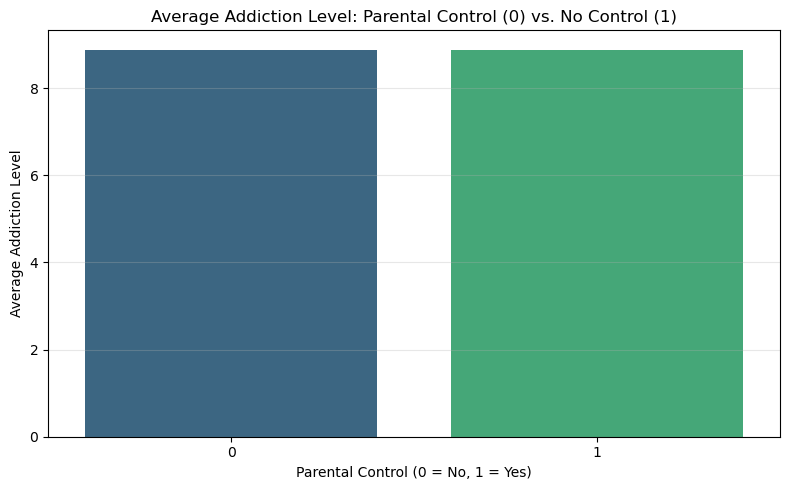

In [32]:
# Parental_Control and average Addiction_Level
control_avg = phone_usage.groupby(by='Parental_Control')['Addiction_Level'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=control_avg, x='Parental_Control', y='Addiction_Level', palette='viridis')

plt.title('Average Addiction Level: Parental Control (0) vs. No Control (1)')
plt.xlabel('Parental Control (0 = No, 1 = Yes)')
plt.ylabel('Average Addiction Level')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Observation**: no clear relationship, potentially this feature can be dropped

### **3.2. Psychological Correlates**

**a. Self-esteem**

Hypothesis 5: Low self-esteem and a high need for social approval are potential predictors of problematic use. Conversely, those with high self-esteem demonstrate less of this tendency.

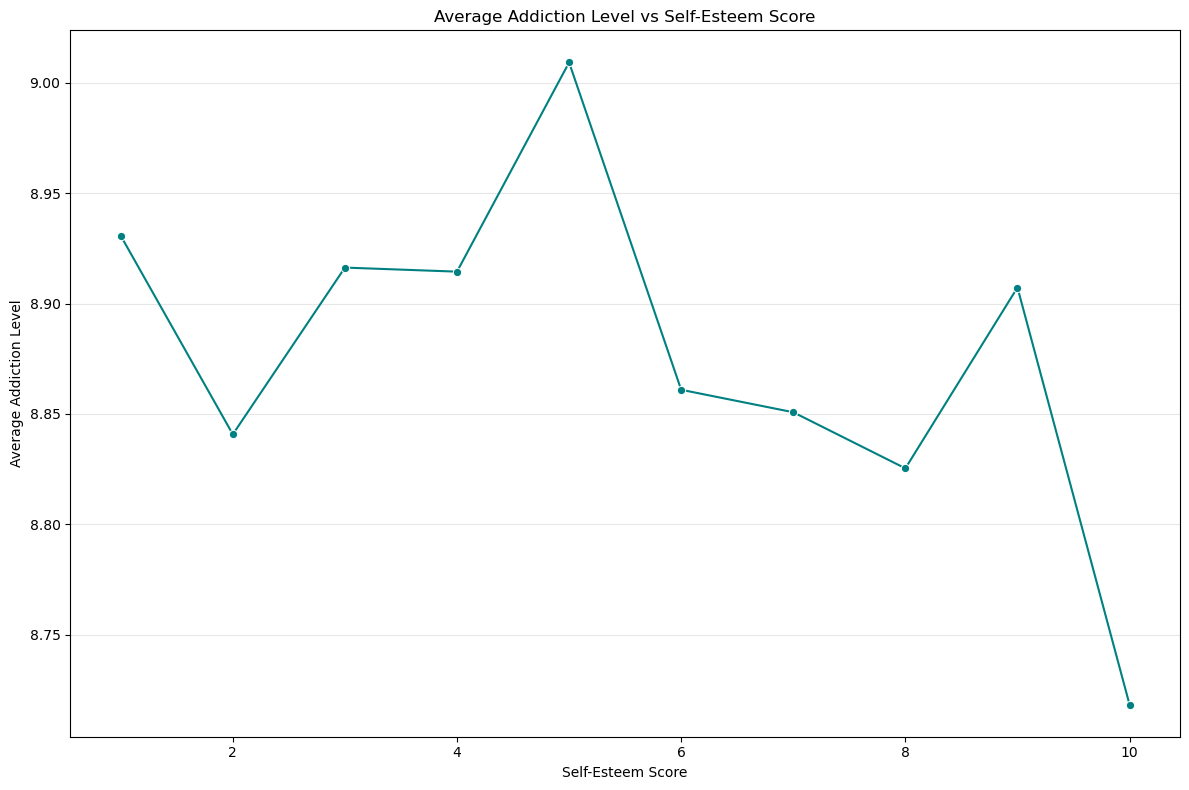

In [33]:
# Self_Esteem & Addiction_Level
esteem_addiction = phone_usage.groupby(by='Self_Esteem')['Addiction_Level'].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.lineplot(data=esteem_addiction, x='Self_Esteem', y='Addiction_Level', marker='o', color='teal')

plt.title('Average Addiction Level vs Self-Esteem Score')
plt.xlabel('Self-Esteem Score')
plt.ylabel('Average Addiction Level')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:** The notable drop at Self-Esteem score 10 (8.73) could suggest highly confident teens use phones less compulsively, but with so few data points at the extremes this is unreliable. 
No meaningful relationship exists between self-esteem and addiction level

### **3.3. Sleep and Physical Health**

**a. Sleep quality**

Hypothesis 6: Students with greater mobile phone addiction showed a significantly higher probability of poor sleep quality. Higher points on the Mobile Phone Problem Use Scale (MPPUS) correlate to greater deterioration in sleep quality measured by the Pittsburgh Sleep Quality scale.

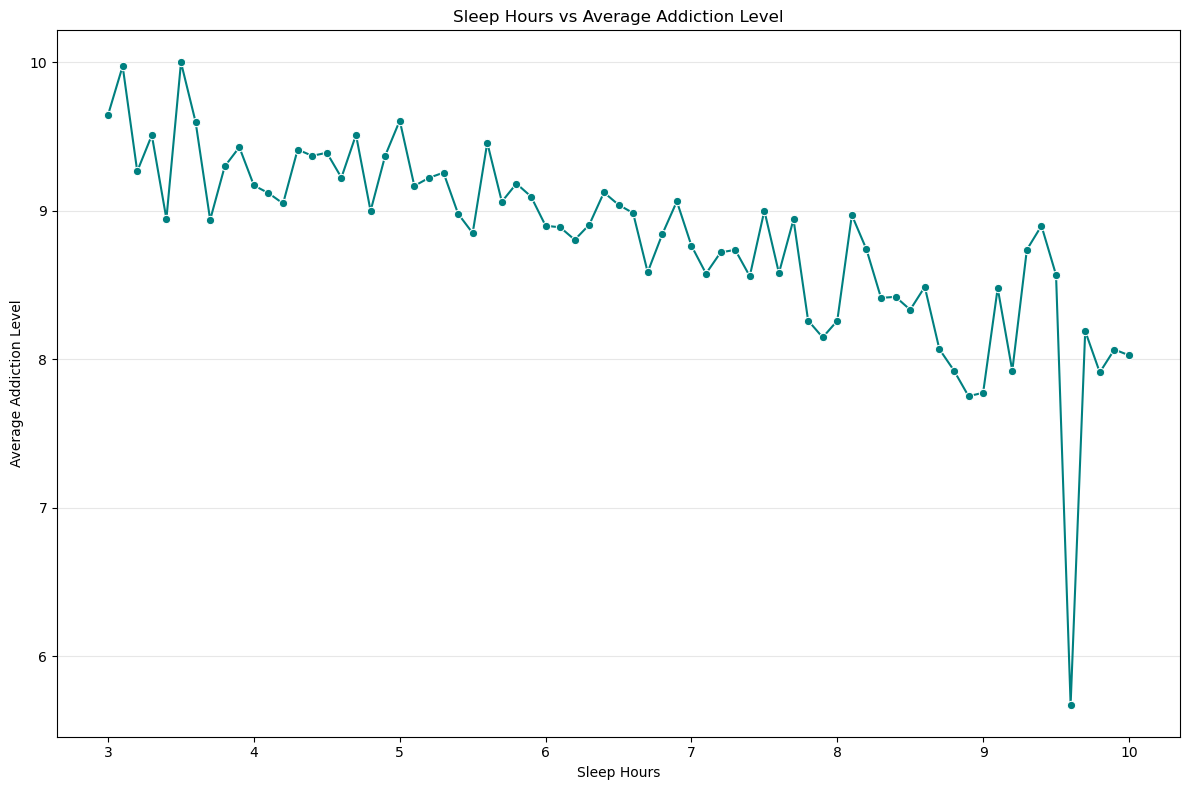

In [34]:
# Sleep_Hours with Addiction_Level
sleep_addiction = phone_usage.groupby(by='Sleep_Hours')['Addiction_Level'].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.lineplot(data=sleep_addiction, x='Sleep_Hours', y='Addiction_Level', marker='o', color='teal')

plt.title('Sleep Hours vs Average Addiction Level')
plt.xlabel('Sleep Hours')
plt.ylabel('Average Addiction Level')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


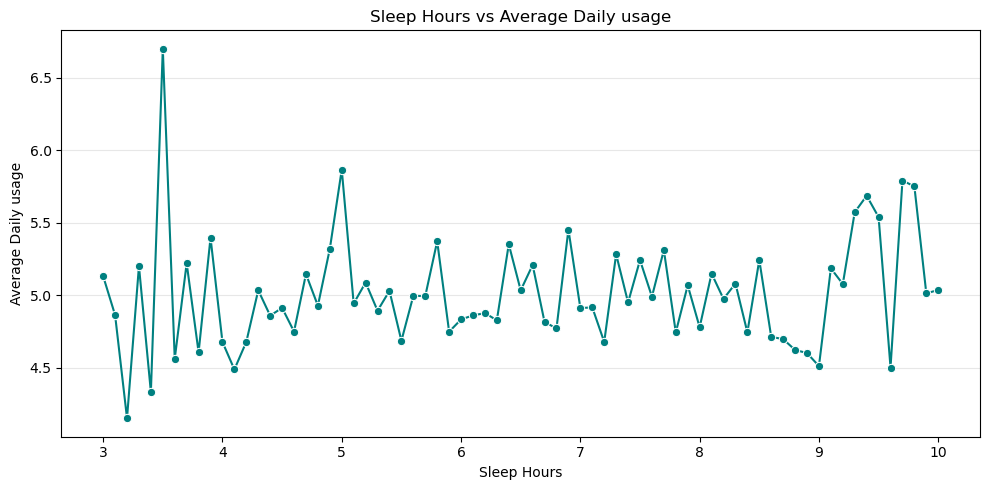

In [35]:
# Sleep hours vs Daily_usage_hours 
sleep_usage = phone_usage.groupby(by='Sleep_Hours')['Daily_Usage_Hours'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=sleep_usage, x='Sleep_Hours', y='Daily_Usage_Hours', marker='o', color='teal')

plt.title('Sleep Hours vs Average Daily usage')
plt.xlabel('Sleep Hours')
plt.ylabel('Average Daily usage')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:** The downward trend is visible, potentially suggests that higher addiction correlates with less sleep, supporting the Hypothesis

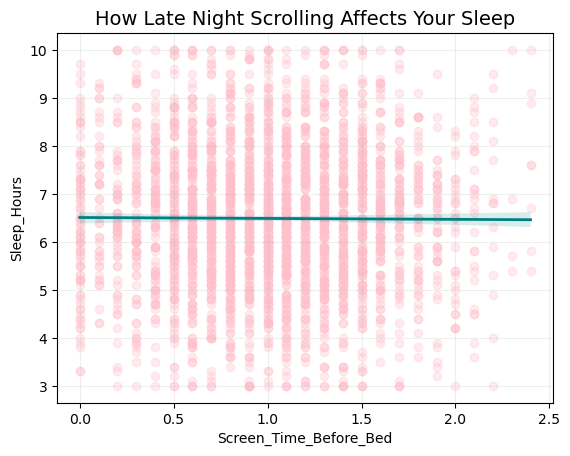

In [36]:
# How does screen time before bed relate to sleep duration?
sns.regplot(data=phone_usage, x='Screen_Time_Before_Bed', y='Sleep_Hours', 
            scatter_kws={'color': 'pink', 'alpha': 0.3}, 
            line_kws={'color': 'teal', 'linewidth': 2})

plt.title('How Late Night Scrolling Affects Your Sleep', fontsize=14)
plt.grid(True, alpha=0.2)
plt.show()

**Observation**: The regression line is almost completely flat, which means screen time before bed alone does not meaningfully reduce sleep duration in this dataset.

**b. Disturbances**

Hypothesis 7: Frequent and constant checking of phone in very brief periods of time with insomnia and sleep disturbances.

In [37]:
# Sleep Efficiency Ratio 
plot_df['Sleep_Efficiency'] = (plot_df['Sleep_Hours'] / (plot_df['Sleep_Hours']+plot_df['Screen_Time_Before_Bed'])).round(2)

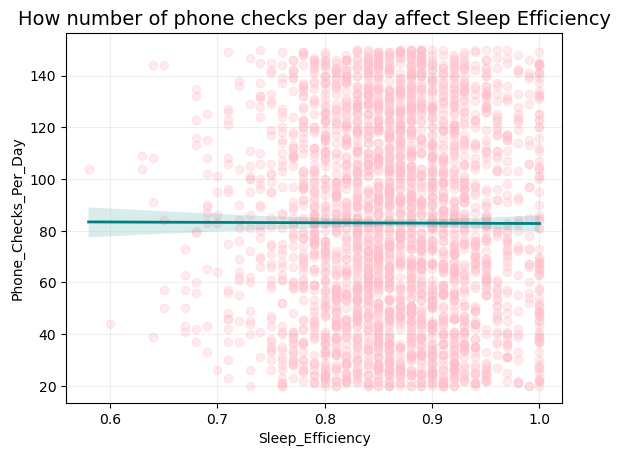

In [38]:
# Relationship between "Sleep_Efficiency" and 'Phone_Checks_Per_Day'
sns.regplot(data=plot_df, x='Sleep_Efficiency', y='Phone_Checks_Per_Day', 
            scatter_kws={'color': 'pink', 'alpha': 0.3}, 
            line_kws={'color': 'teal', 'linewidth': 2})

plt.title('How number of phone checks per day affect Sleep Efficiency', fontsize=14)
plt.grid(True, alpha=0.2)
plt.show()


**Observation:** Flat regression line with widely scattered points — no relationship between how frequently teens check their phone and their sleep efficiency.

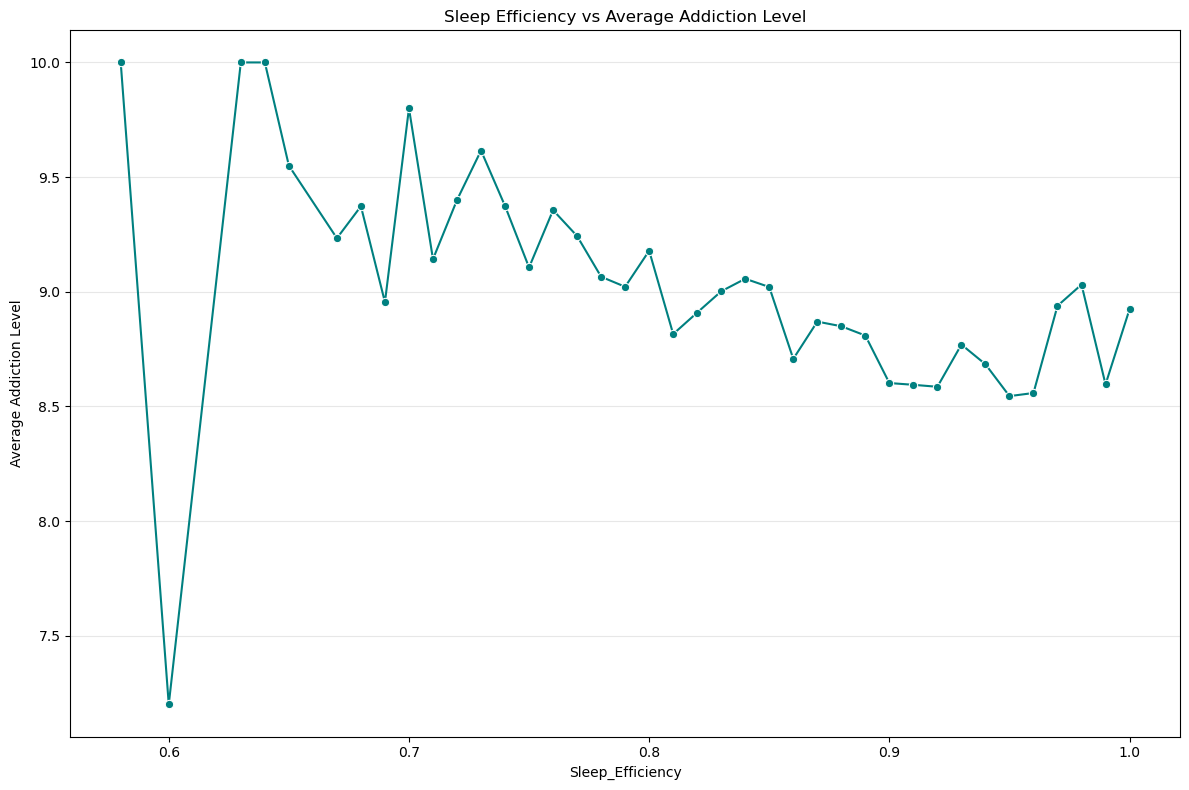

In [39]:
sefficiency_addiction = plot_df.groupby(by='Sleep_Efficiency')['Addiction_Level'].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.lineplot(data=sefficiency_addiction, x='Sleep_Efficiency', y='Addiction_Level', marker='o', color='teal')

plt.title('Sleep Efficiency vs Average Addiction Level')
plt.xlabel('Sleep_Efficiency')
plt.ylabel('Average Addiction Level')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation**: There is a general downward trend, supports the idea that poor sleep quality is associated with higher addiction

### **3.4. Routines**

In [40]:
# Phone_Usage_Purpose (non-addicted/addicted) 
# Binning 'Addiction_Level' into different categories 
plot_df['Addiction_Level_Category'] = pd.cut(plot_df['Addiction_Level'],
    bins=[-np.inf, 4.0, 9.0, np.inf],
    labels=[0, 1, 2]  # 0=Low, 1=Medium, 2=High
)

# Replace original Addiction_Level with categorical version
plot_df.drop(columns=['Addiction_Level'], inplace=True)
plot_df.rename(columns={'Addiction_Level_Category': 'Addiction_Level'}, inplace=True)

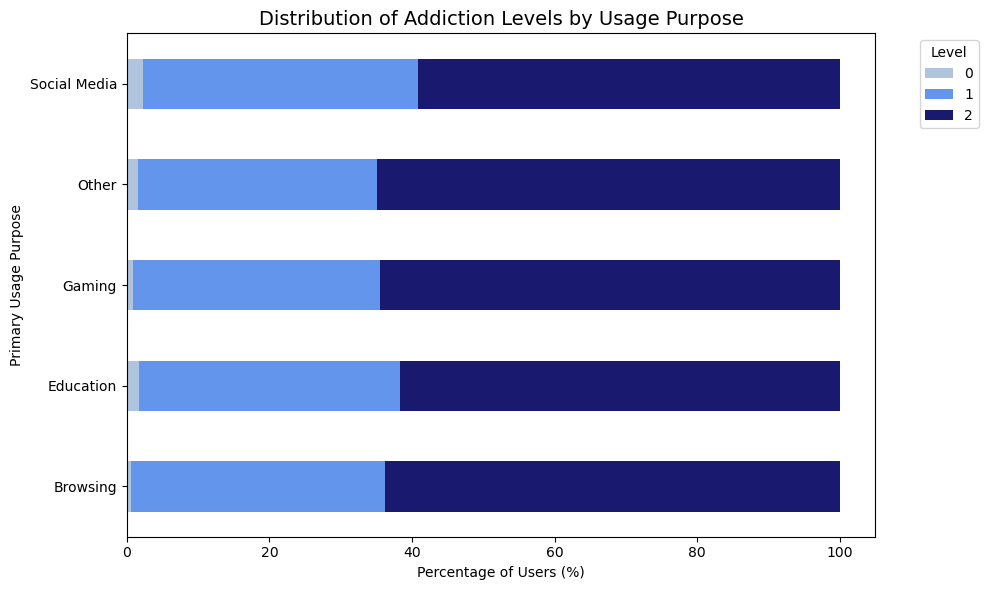

In [41]:
# calculates the percentage of each addiction level within each purpose
analysis_df = pd.crosstab(plot_df['Phone_Usage_Purpose'], 
                          plot_df['Addiction_Level'], 
                          normalize='index') * 100

colors = ['lightsteelblue', 'cornflowerblue', 'midnightblue'] 
ax = analysis_df.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)

plt.title('Distribution of Addiction Levels by Usage Purpose', fontsize=14)
plt.xlabel('Percentage of Users (%)')
plt.ylabel('Primary Usage Purpose')
plt.legend(title='Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

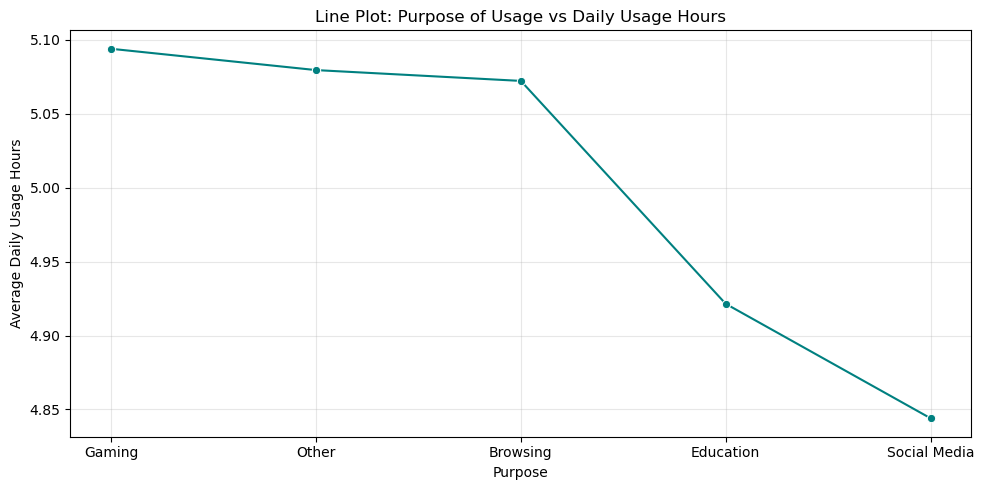

In [42]:
# Which usage category accounts for the peak daily screen time?
# Phone_Usage_Purpose
app_gender = phone_usage.groupby('Phone_Usage_Purpose')['Daily_Usage_Hours'].mean().reset_index()
app_gender.sort_values(by = ['Daily_Usage_Hours'], ascending = False, inplace=True)


plt.figure(figsize=(10,5))
sns.lineplot(x='Phone_Usage_Purpose', y = 'Daily_Usage_Hours', data = app_gender, marker='o', color = 'teal')

plt.title('Line Plot: Purpose of Usage vs Daily Usage Hours')
plt.xlabel('Purpose')
plt.ylabel('Average Daily Usage Hours')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

**Observation:** Gaming drives the highest average daily usage, exceeding 5 hours per day. Social Media surprisingly shows the lowest average daily usage though it remains a high-risk category for addiction intensity

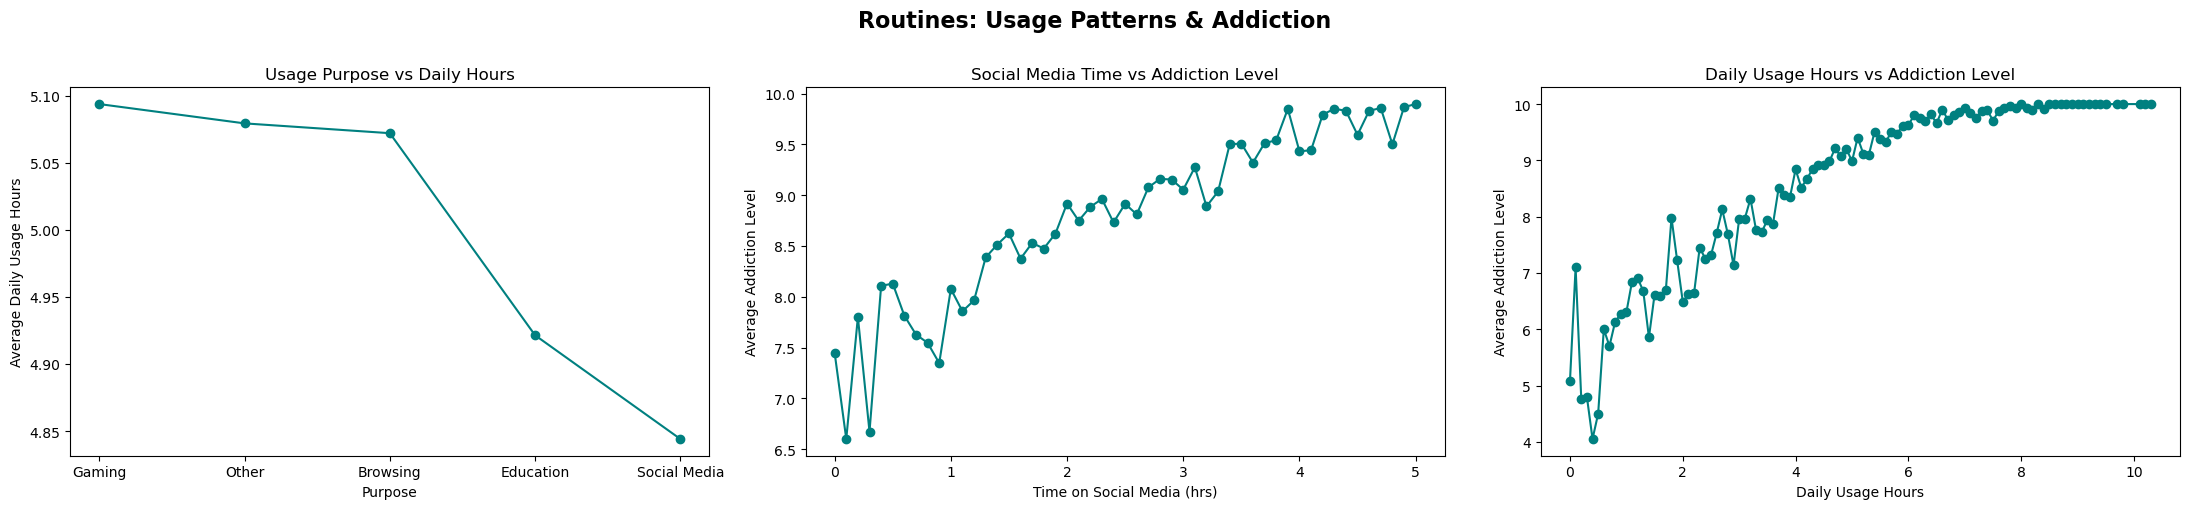

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Chart 1: Usage Purpose vs Daily Usage Hours
app_usage = phone_usage.groupby('Phone_Usage_Purpose')['Daily_Usage_Hours'].mean().reset_index()
app_usage.sort_values(by='Daily_Usage_Hours', ascending=False, inplace=True)
axes[0].plot(app_usage['Phone_Usage_Purpose'], app_usage['Daily_Usage_Hours'], marker='o', color='teal')
axes[0].set_title('Usage Purpose vs Daily Hours')
axes[0].set_xlabel('Purpose')
axes[0].set_ylabel('Average Daily Usage Hours')

# Chart 2: Time on Social Media vs Addiction Level
social_addiction = phone_usage.groupby(by='Time_on_Social_Media', observed=True)['Addiction_Level'].mean().reset_index()
axes[1].plot(social_addiction['Time_on_Social_Media'], social_addiction['Addiction_Level'], marker='o', color='teal')
axes[1].set_title('Social Media Time vs Addiction Level')
axes[1].set_xlabel('Time on Social Media (hrs)')
axes[1].set_ylabel('Average Addiction Level')

# Chart 3: Daily Usage Hours vs Addiction Level
usage_addiction = phone_usage.groupby('Daily_Usage_Hours', observed=True)['Addiction_Level'].mean().reset_index()
axes[2].plot(usage_addiction['Daily_Usage_Hours'], usage_addiction['Addiction_Level'], marker='o', color='teal')
axes[2].set_title('Daily Usage Hours vs Addiction Level')
axes[2].set_xlabel('Daily Usage Hours')
axes[2].set_ylabel('Average Addiction Level')

plt.suptitle('Routines: Usage Patterns & Addiction', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations**: 
- Gaming drives the highest average daily usage, exceeding 5 hours per day. Social Media surprisingly shows the lowest average daily usage though it remains a high-risk category for addiction intensity
- There is a strong, positive correlation between daily usage hours and addiction level. The sharpest increase in addiction level occurs within the first 2 hours of social media usage.


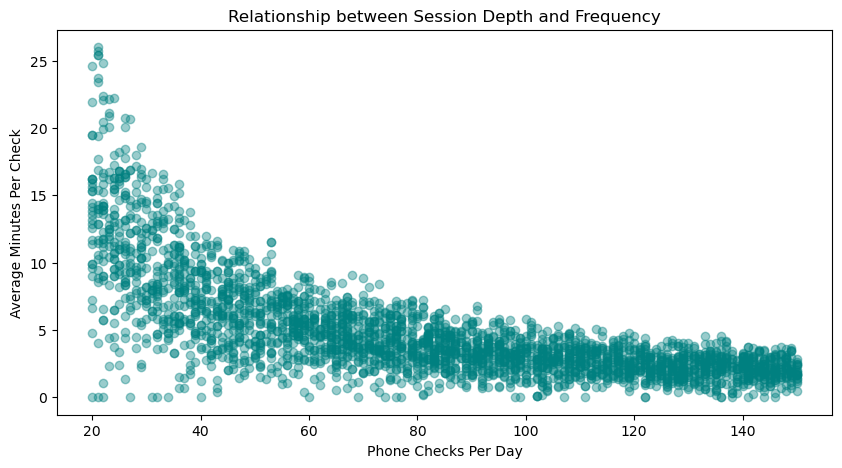

In [44]:
# Do teens with high phone checks have different usage patterns?

# To check what is length between each phone check session? 
# Minutes_Per_Check = Total hours * 60 minutes) / Number of checks
plt.figure(figsize=(10, 5))
plt.scatter(phone_usage['Phone_Checks_Per_Day'], 
    (phone_usage['Daily_Usage_Hours'] * 60) / phone_usage['Phone_Checks_Per_Day'], 
    alpha=0.4, 
    color='teal')

plt.title('Relationship between Session Depth and Frequency')
plt.xlabel('Phone Checks Per Day')
plt.ylabel('Average Minutes Per Check')
plt.show()

**Observation**: A strong inverse relationship. This relationship proves that high-frequency users suffer from severe attention fragmentation, which is a core diagnostic feature of digital addiction. Meaning the more often a user checks their phone, the less likely they are to be doing anything substantial on it.

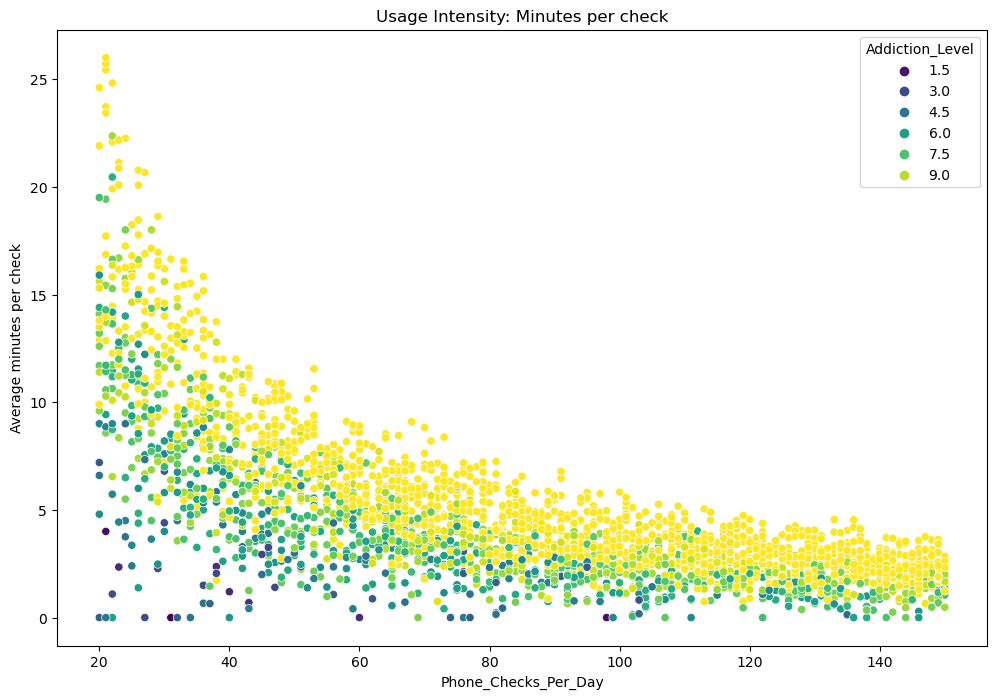

In [45]:
# see the relationship between usage intensity and addiction level
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=phone_usage['Phone_Checks_Per_Day'], 
    y=(phone_usage['Daily_Usage_Hours'] * 60) / phone_usage['Phone_Checks_Per_Day'],
    hue=phone_usage['Addiction_Level'],
    palette='viridis'
)

plt.title('Usage Intensity: Minutes per check')
plt.ylabel('Average minutes per check')
plt.show()

**Observation:** The highest addiction levels re concentrated in the "high frequency" zone, even when individual sessions are short.

#### **3.5. Overall relationship**

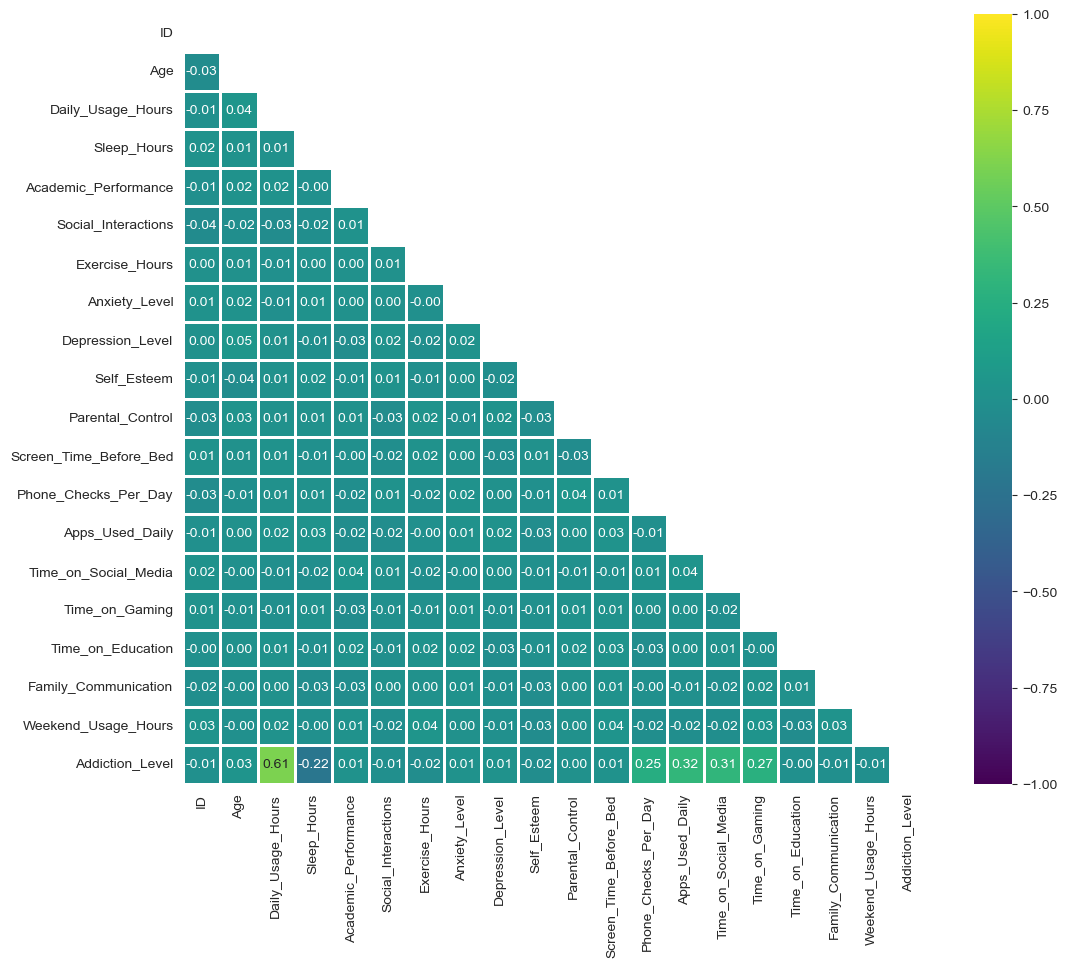

In [46]:
plt.figure(figsize=(12,10))
corr = phone_usage.select_dtypes(include='number').corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style('white'): 
    ax=sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, cmap = 'viridis', annot = True, fmt='.2f', linewidths=2)
    plt.show()

## 5. Data Preprocessing

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (accuracy_score, recall_score, f1_score, classification_report, 
                            confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score)

### *5.1. Feature Engineering*

*a. Create new features*

In [48]:
# 1. Social Displacement 
phone_usage['Social_Displacement'] = (
    (phone_usage['Time_on_Social_Media'] + phone_usage['Time_on_Gaming']) /
    (phone_usage['Social_Interactions'] + phone_usage['Exercise_Hours'])
    .replace(0, float('nan')))

# 2. Check Intensity (checks per hour)
phone_usage['Check_Intensity'] = (phone_usage['Phone_Checks_Per_Day'] 
                                  / phone_usage['Daily_Usage_Hours']).replace(0, float('nan'))


# 3. Sleep Efficiency Ratio
phone_usage['Sleep_Efficiency'] = (phone_usage['Sleep_Hours'] /
    (phone_usage['Sleep_Hours'] + phone_usage['Screen_Time_Before_Bed']))

In [49]:
# Check for any inf or NaN created
print(phone_usage[['Sleep_Efficiency', 'Social_Displacement', 
                    'Check_Intensity']].isin([float('inf'), float('-inf')]).sum())
print(phone_usage[['Sleep_Efficiency', 'Social_Displacement', 
                    'Check_Intensity']].isna().sum())

Sleep_Efficiency        0
Social_Displacement     0
Check_Intensity        25
dtype: int64
Sleep_Efficiency        0
Social_Displacement    30
Check_Intensity         0
dtype: int64


In [50]:
# Handle the NaN value 
phone_usage = phone_usage.replace([np.inf, -np.inf], np.nan)
phone_usage['Check_Intensity']    = phone_usage['Check_Intensity'].fillna(phone_usage['Check_Intensity'].median())
phone_usage['Social_Displacement'] = phone_usage['Social_Displacement'].fillna(phone_usage['Social_Displacement'].median())

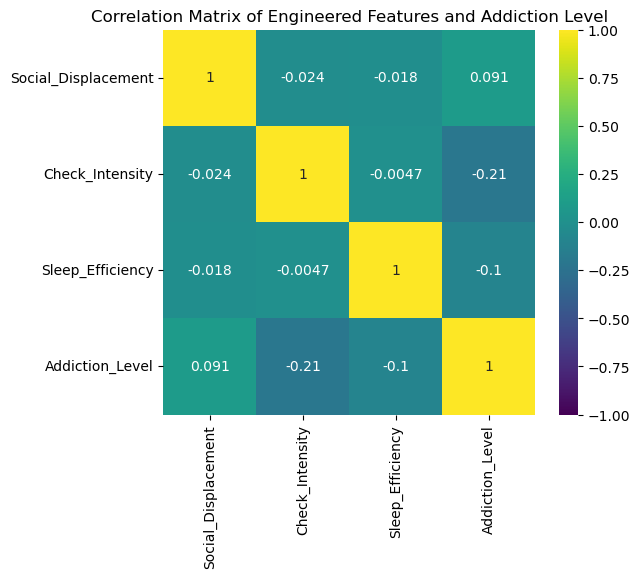

In [51]:
# Check correlation
new_features = ['Social_Displacement', 'Check_Intensity', 'Sleep_Efficiency', 'Addiction_Level', ]

corr = phone_usage[new_features].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Engineered Features and Addiction Level")
plt.show()

In [52]:
print(phone_usage['Addiction_Level'].describe())
print(f"\nMedian: {phone_usage['Addiction_Level'].median()}")
print(f"Unique values: {sorted(phone_usage['Addiction_Level'].unique())}")

count    2953.000000
mean        8.877616
std         1.614934
min         1.000000
25%         8.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: Addiction_Level, dtype: float64

Median: 10.0
Unique values: [1.0, 1.4, 2.0, 2.1, 2.2, 2.3, 2.4, 2.6, 2.8, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8.0, 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9.0, 9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 9.8, 9.9, 10.0]


In [53]:
# Binning continuous target value 'Addiction_Level' into different categories 

phone_usage['Addiction_Level_Category'] = pd.cut(
    phone_usage['Addiction_Level'],
    bins=[-np.inf, 4, 9, np.inf],
    labels=[0, 1, 2] # 0 = misuse/abuse
                     # 1 = dependence 
                     # 2 = addiction
)

# Check balance
counts = phone_usage['Addiction_Level_Category'].value_counts().sort_index()
percentages = phone_usage['Addiction_Level_Category'].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    'Count': counts,
    'Percentage': percentages.round(2).astype(str) + '%'
})

print(summary)

   Count Percentage
0     42      1.42%
1   1056     35.76%
2   1855     62.82%


In [54]:
# Replace original Addiction_Level with categorical version
phone_usage.drop(columns=['Addiction_Level'], inplace=True)
phone_usage.rename(columns={'Addiction_Level_Category': 'Addiction_Level'}, inplace=True)

In [55]:
phone_usage.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours',
       'Social_Displacement', 'Check_Intensity', 'Sleep_Efficiency',
       'Addiction_Level'],
      dtype='object')

*b. Drop features*

In [56]:
# feature selection 
# remove 'school_grade' because carry the same info as 'Age'

# Drop leakage features 
drop_cols = ['ID', 'Name',     # identifiers 
             'School_Grade',   # carry the same info as 'Age'
             'Location',       # number of unique values ~ rows
             # leakage features
             'Daily_Usage_Hours', 

            # Near zero correlation with Addiction_Level
            'Academic_Performance', 'Screen_Time_Before_Bed',
            'Social_Interactions','Exercise_Hours', 'Self_Esteem',
            'Anxiety_Level', 'Depression_Level', 'Parental_Control',
            'Family_Communication', 'Time_on_Education']

phone_usage = phone_usage.drop(columns=drop_cols, errors="ignore")


In [57]:
# Final size & number of columns
phone_usage.shape


(2953, 13)

In [58]:
cat_features = ['Gender', 'Phone_Usage_Purpose']
num_features = ['Age', 'Sleep_Hours','Phone_Checks_Per_Day',
                'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming',
                'Weekend_Usage_Hours','Social_Displacement', 
                'Check_Intensity', 'Sleep_Efficiency']


### *5.2. Data Splitting*

In [59]:
# split the dataset 
from sklearn.model_selection import train_test_split

y = phone_usage['Addiction_Level']
X = phone_usage.drop(columns = ['Addiction_Level'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)

In [60]:
print('X train shape: ', X_train.shape)
print('y train shape:', y_train.shape)
print('X test shape: ', X_test.shape)
print('y test shape:', y_test.shape)

X train shape:  (2362, 12)
y train shape: (2362,)
X test shape:  (591, 12)
y test shape: (591,)


### *5.3. Data Handling before Training *(to avoid leakage)**

In [61]:
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())]) #standardises values to mean=0, std=1

categorical_transformer = Pipeline(steps=
                                    [("onehot", OneHotEncoder(handle_unknown="ignore"))])
                                     #converts text categories into numbers
                                     # use one-hot-encoding since values have few categories and no order

preprocess = ColumnTransformer(transformers=
                               [("num", numeric_transformer, num_features), #apply numeric pipe to number cols
                                ("cat", categorical_transformer, cat_features)]) # apply cat pipe to text cols

In [62]:
X_train_processed = preprocess.fit_transform(X_train)  
X_test_processed  = preprocess.transform(X_test)        

### *5.4. Visualize cluster*

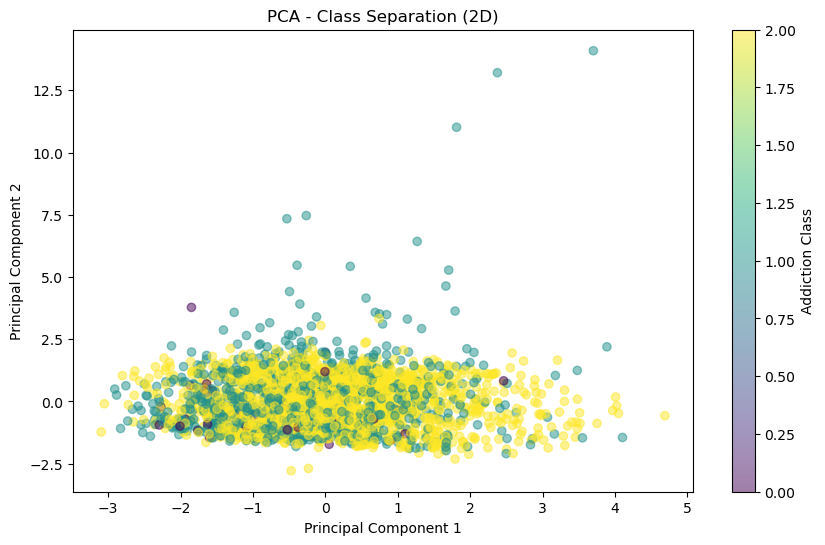

In [63]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_processed)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=y_train, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Addiction Class')
plt.title('PCA - Class Separation (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

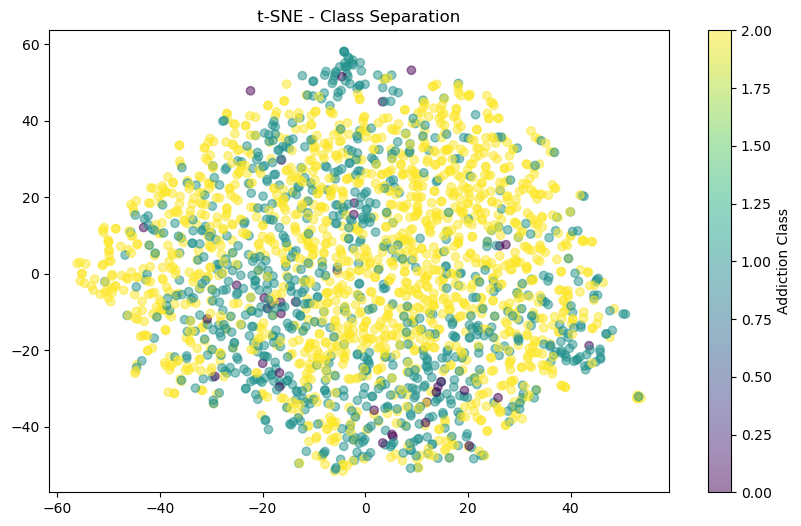

In [64]:
from sklearn.manifold import TSNE
# t-SNE (t-distributed Stochastic Neighbour Embedding) is a dimensionality reduction technique used to visualise high-dimensional data in 2D
# t-SNE is used as a sanity check - to visually confirm whether the three addiction classes (Misuse, Dependence, Addiction) form distinguishable clusters in the feature space. 


tsne = TSNE(n_components=2, random_state=42) # Reduce to 2 dimensions for plotting
X_tsne = tsne.fit_transform(X_train_processed)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=y_train, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Addiction Class')
plt.title('t-SNE - Class Separation')
plt.show()

## 6. Training the model 

**Model selection**: 
- **Logistic Regression:** use a interpretable baseline, assume linearity 
- **Random Forest**: handle non-linearity & produces feature importance 
- **Gradient Boosting:** while Random Forest builds trees in parallel independently, Gradient 
Boosting builds them sequentially. Use in contrast with RF to compare performance 
- **AdaBoost:** used as a direct contrast to Gradient Boosting. Both are boosting methods, but AdaBoost reweights misclassified samples at each round rather than fitting residuals
- **MLP**: neural baseline, to capture complex interactions 

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

In [66]:
# Define Classifiers 
base_dt = DecisionTreeClassifier(max_depth=11, class_weight='balanced', random_state=42)

classifiers = [
    ('Logistic Regression', LogisticRegression(class_weight='balanced', random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('AdaBoost', AdaBoostClassifier(base_estimator=base_dt, n_estimators=100, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('Multi-layer Perceptron', MLPClassifier(max_iter=500, random_state=42)),
]

# Training and Evaluation

results_list = []

print("📊 Training Models and Calculating Metrics...\n")

for name, clf in classifiers:
    clf.fit(X_train_processed, y_train)
    y_pred = clf.predict(X_test_processed)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro') # Added F1-Score
    rec_class_2 = recall_score(y_test, y_pred, average=None)[2] 
    
    results_list.append({
        'Model': name, 
        'Accuracy': acc, 
        'F1_Score': f1, 
        'Recall_Class_2': rec_class_2
    })
    
    print(f"{name:25} | Acc: {acc:.4f} | F1: {f1:.4f} | Recall (C2): {rec_class_2:.4f}")

📊 Training Models and Calculating Metrics...

Logistic Regression       | Acc: 0.8613 | F1: 0.6274 | Recall (C2): 0.9141
Random Forest             | Acc: 0.8663 | F1: 0.5698 | Recall (C2): 0.9695
AdaBoost                  | Acc: 0.8883 | F1: 0.5869 | Recall (C2): 0.9778
Gradient Boosting         | Acc: 0.9289 | F1: 0.6202 | Recall (C2): 0.9723
Multi-layer Perceptron    | Acc: 0.9543 | F1: 0.7703 | Recall (C2): 0.9723


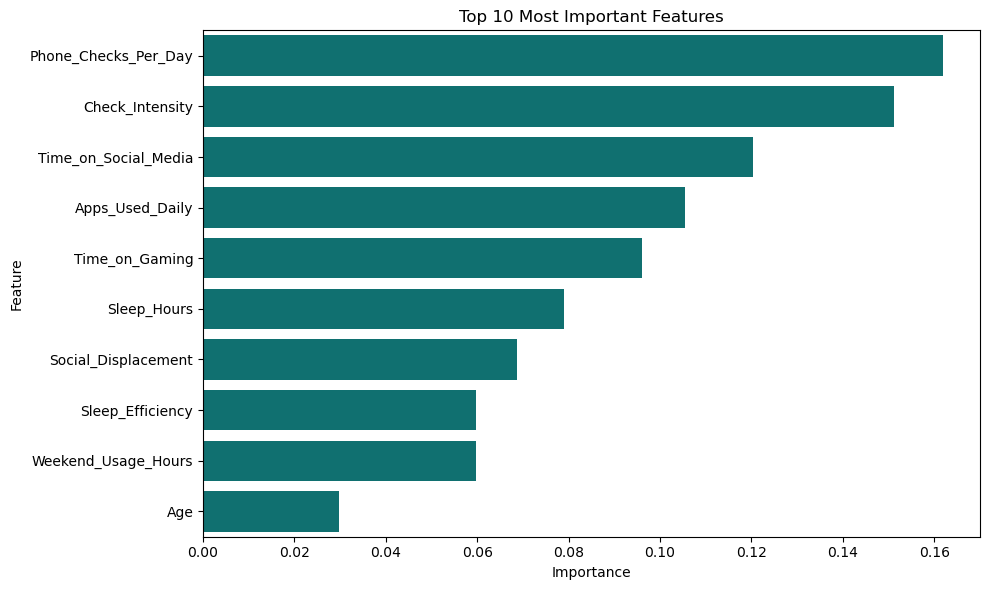

In [67]:
# Extract individual models for later use
trained_models = {name: clf for name, clf in classifiers}

mlp = trained_models['Multi-layer Perceptron']
gbc = trained_models['Gradient Boosting']
rf  = trained_models['Random Forest']

# Sort by Recall_Class_2 
results_df = pd.DataFrame(results_list).sort_values(by='Recall_Class_2', ascending=False)

# Feature Importance (Using Random Forest)
feat_importance = pd.DataFrame({'Feature': num_features + 
                                list(preprocess.named_transformers_['cat'].named_steps['onehot']
                                     .get_feature_names_out(cat_features)), 
                                     'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Importance', y='Feature', color='teal')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

In [68]:
# Overfitting check — cross-validation on all models
print("Cross-Validation Scores (5-fold, scoring=accuracy)\n")
for name, clf in classifiers:
    cv = cross_val_score(clf, X_train_processed, y_train, cv=5, scoring='accuracy')
    print(f"{name:25} | CV Mean: {cv.mean():.4f} | CV Std: {cv.std():.4f}")

Cross-Validation Scores (5-fold, scoring=accuracy)

Logistic Regression       | CV Mean: 0.8400 | CV Std: 0.0114
Random Forest             | CV Mean: 0.8412 | CV Std: 0.0239
AdaBoost                  | CV Mean: 0.8692 | CV Std: 0.0168
Gradient Boosting         | CV Mean: 0.9039 | CV Std: 0.0122
Multi-layer Perceptron    | CV Mean: 0.9213 | CV Std: 0.0075


## 7. Evaluate models

**Goal:** correctly identify Class 2 (Addiction) and ensure no one in Class 2 is missed. 
- a missed diagnosis (false negative) is far more harmful than a false alarm. A model that labels an addicted teen as "fine" fails the entire purpose of this analysis.

**Metrics:**
- **Recall (for class 2)** | Primary | Minimises missed addictions — a false negative has real welfare cost
- **Macro F1** | Secondary | Balances performance across all 3 classes, penalises ignoring minorities |
- **Accuracy** | Baseline only | Accuracy is reported for completeness


In [69]:
# Select best model from evaluation results
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
y_pred          = best_model.predict(X_test_processed)

print(f"Best model by Recall (Class 2): {best_model_name}\n")
print(classification_report(y_test, y_pred,
      target_names=['Misuse', 'Dependence', 'Addiction']))

Best model by Recall (Class 2): AdaBoost

              precision    recall  f1-score   support

      Misuse       0.00      0.00      0.00         6
  Dependence       0.92      0.77      0.84       224
   Addiction       0.87      0.98      0.92       361

    accuracy                           0.89       591
   macro avg       0.60      0.58      0.59       591
weighted avg       0.88      0.89      0.88       591



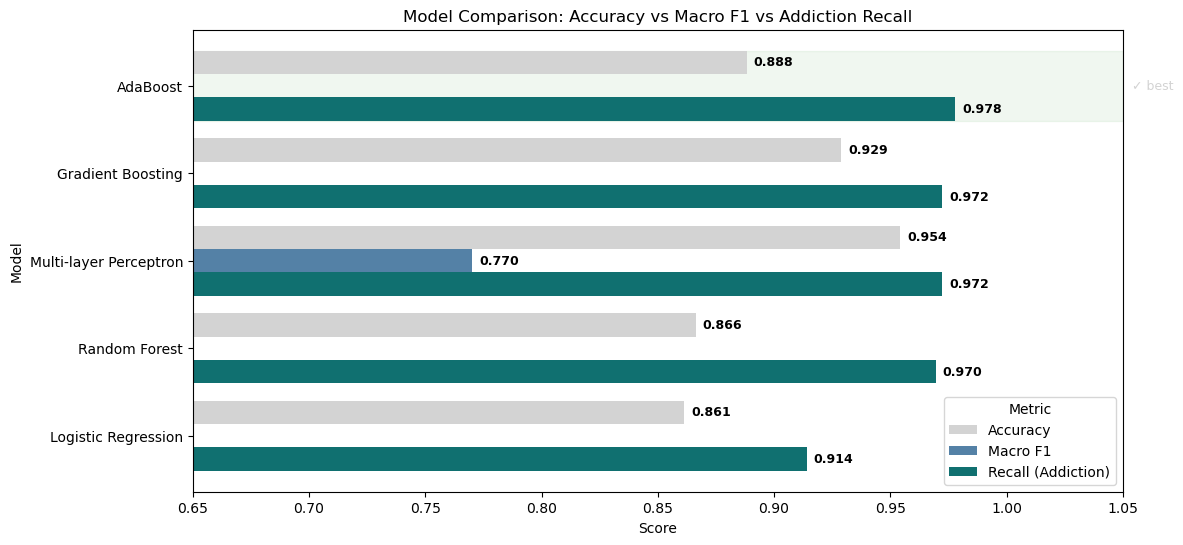

In [70]:
# Model comparison: Accuracy, Macro F1, Recall (Class 2) 
df_plot = results_df[['Model', 'Accuracy', 'F1_Score', 'Recall_Class_2']].melt(id_vars='Model')

# Rename for cleaner legend labels
df_plot['variable'] = df_plot['variable'].map({'Accuracy':      'Accuracy',
                                               'F1_Score':      'Macro F1',
                                               'Recall_Class_2':'Recall (Addiction)'})

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=df_plot, x='value', y='Model', hue='variable',
            palette=['lightgrey', 'steelblue', 'teal'], ax=ax)

ax.set_title('Model Comparison: Accuracy vs Macro F1 vs Addiction Recall')
ax.set_xlabel('Score')
ax.set_xlim(0.65, 1.05)
ax.legend(title='Metric', loc='lower right', fontsize=10)

# Value labels on each bar
for p in ax.patches:
    val = p.get_width()
    if val > 0.65:
        ax.text(val + 0.003, p.get_y() + p.get_height() / 2, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# Highlight best model row
best_idx = list(results_df['Model']).index(best_model_name)
ax.axhspan(best_idx - 0.4, best_idx + 0.4,
           color='green', alpha=0.06, zorder=0)
ax.text(1.01, best_idx, '✓ best',
        va='center', fontsize=9,
        color='lightgrey', transform=ax.get_yaxis_transform())

plt.show()

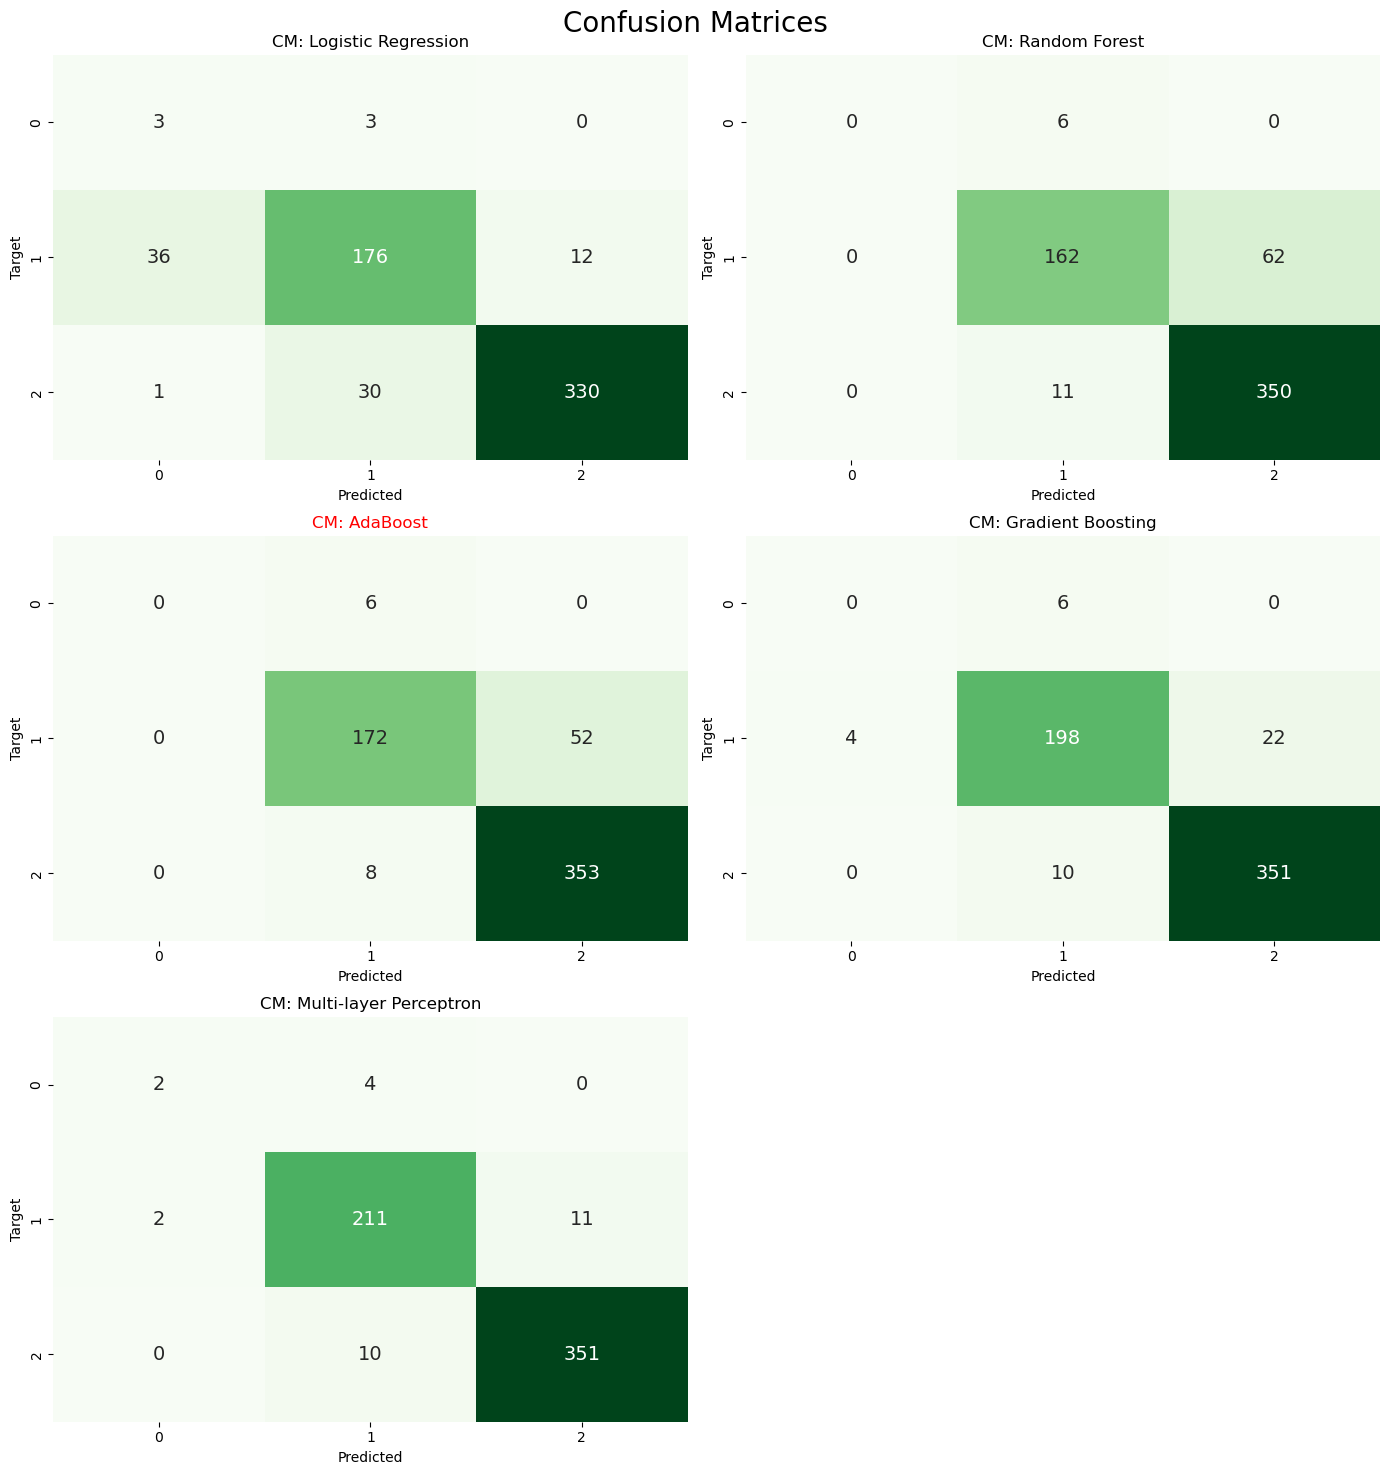

In [71]:
# Confusion matrices 
n_models = len(classifiers)
n_cols   = 2
n_rows   = math.ceil(n_models / n_cols)

# Setup the grid (4 rows, 2 columns for your 8 models)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, n_rows*5))
axes = axes.flatten()

for idx, (name, model) in enumerate(classifiers):
    # Get predictions
    y_pred = model.predict(X_test_processed)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot using a heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx], 
                cbar=False, annot_kws={"size": 14})

    # Highlight best model
    title = f'CM: {name}'
    if name == best_model_name:
        title += '  ✓ best'
        axes[idx].title.set_color('red')
    
    # Styling each subplot
    axes[idx].set_title(f'CM: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Target')

for j in range(len(classifiers), len(axes)): # hide unused suplots 
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95) 
plt.suptitle('Confusion Matrices', fontsize=20)
plt.show()

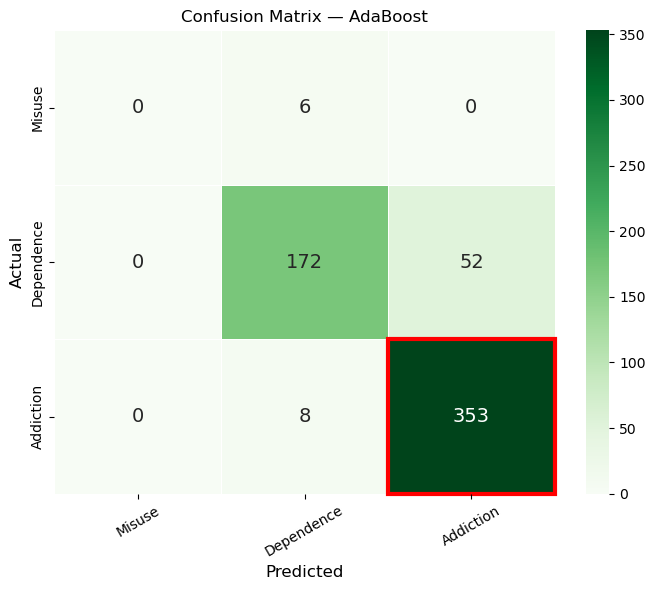


Of all truly addicted teens in the test set:
  Correctly identified : 353 (97.8%)
  Missed (false negative): 8 (2.2%)


In [72]:
# Detailed confusion matrix for best model only
class_names = ['Misuse', 'Dependence', 'Addiction']

y_pred_best = best_model.predict(X_test_processed)
cm_best     = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={'size': 14},
            linewidths=0.5,
            ax=ax)

ax.set_title(f'Confusion Matrix — {best_model_name}')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual',    fontsize=12)
ax.tick_params(axis='x', rotation=30)

# Highlight the Addiction true positive cell with a border
ax.add_patch(plt.Rectangle((2, 2), 1, 1,
             fill=False, edgecolor='Red',
             linewidth=3, clip_on=False))

plt.tight_layout()
plt.show()

# Print plain-English interpretation
tn_addiction = cm_best[2, 2]   # correctly identified addicted teens
fn_addiction = cm_best[2, 0] + cm_best[2, 1]  # addicted teens missed

print(f"\nOf all truly addicted teens in the test set:")
print(f"  Correctly identified : {tn_addiction} "
      f"({tn_addiction/(tn_addiction+fn_addiction)*100:.1f}%)")
print(f"  Missed (false negative): {fn_addiction} "
      f"({fn_addiction/(tn_addiction+fn_addiction)*100:.1f}%)")

In [73]:
# ROC Curve 
from sklearn.preprocessing import label_binarize

def plot_multiclass_evaluation(name, model, X_test, y_test):
    y_probs = model.predict_proba(X_test)
    n_classes = y_probs.shape[1]
    
    # Binarize the output for multiclass string/integer labels
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    
    plt.figure(figsize=(10, 6))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (area = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Multiclass ROC - {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

Generating Multiclass Evaluation for Multi-layer Perceptron...


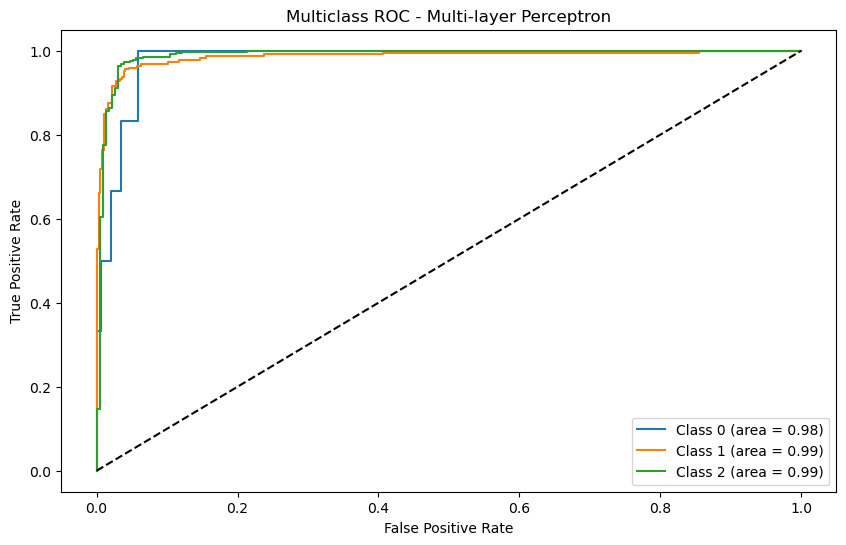

Generating Multiclass Evaluation for Gradient Boosting...


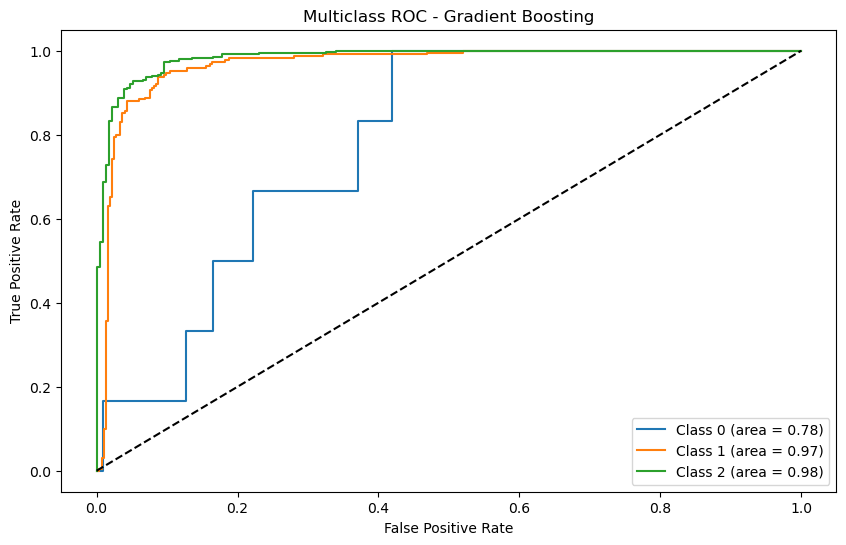

In [74]:
# Call for top 2 models
top_models = [('Multi-layer Perceptron', mlp), 
              ('Gradient Boosting', gbc)]

for name, model in top_models:
    print(f"Generating Multiclass Evaluation for {name}...")
    plot_multiclass_evaluation(name, model, X_test_processed, y_test)

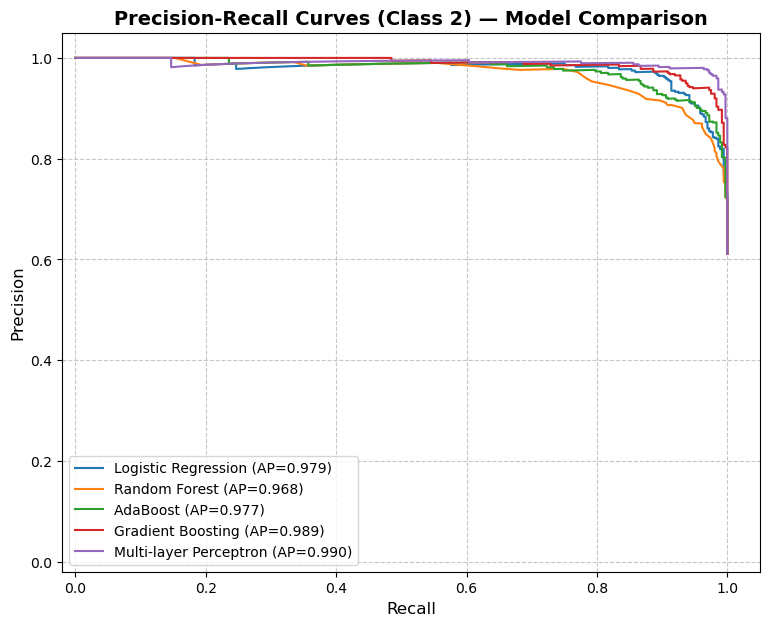

In [75]:
# model comparison 
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Identify the class you want to focus on (e.g., class 1 or 'High')
target_class_index = 2 

plt.figure(figsize=(9, 7))

for name, model in classifiers:
    # 1. Get probability matrix (e.g., shape [n_samples, 3] for 3 classes)
    y_probs = model.predict_proba(X_test_processed)
    
    # 2. Binarize y_test specifically for this class
    # This turns [0, 1, 2] into [0, 1, 0] for the target class
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)
    
    # 3. Calculate Precision/Recall for ONLY the target class
    # We use y_test_bin[:, target_class_index] to isolate the class
    prec, rec, _ = precision_recall_curve(y_test_bin[:, target_class_index], 
                                          y_probs[:, target_class_index])
    
    # 4. Calculate Average Precision
    ap = average_precision_score(y_test_bin[:, target_class_index], 
                                 y_probs[:, target_class_index])
    
    # 5. Plot
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

# Matching your screenshot's styling
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title(f"Precision-Recall Curves (Class {target_class_index}) — Model Comparison", fontsize=14, fontweight='bold')
plt.legend(loc="best", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim([-0.02, 1.05])
plt.ylim([-0.02, 1.05])
plt.show()

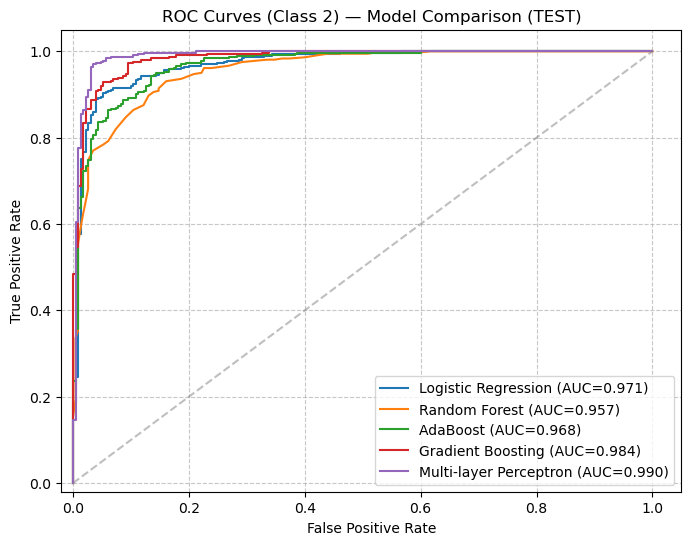

In [76]:
# Choose the class to evaluate (e.g., 1 for 'High Addiction')
target_class_index = 2

plt.figure(figsize=(8, 6))

for name, model in classifiers:
    y_probs = model.predict_proba(X_test_processed)
    
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    fpr, tpr, _ = roc_curve(y_test_bin[:, target_class_index], 
                            y_probs[:, target_class_index])
    
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

# Finalizing the style to match reference
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5) # Diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves (Class {target_class_index}) — Model Comparison (TEST)")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim([-0.02, 1.05])
plt.ylim([-0.02, 1.05])
plt.show()

- The ROC curve plots True Positive Rate (correctly caught addicted teens) against False Positive Rate (non-addicted teens wrongly flagged) across every possible classification threshold.
- an AUC of 0.90 means the model correctly ranks a randomly chosen addicted teen above a randomly chosen non-addicted teen 90% of the time

#### Hyperparameters tuning for Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Each combination will be evaluated via 5-fold cross-validation
param_grid = {
    'n_estimators':    [100, 200],        # More trees generally improves performance up to a point
    'learning_rate':   [0.05, 0.1],       # Lower = slower learning but better generalisation
    'max_depth':       [3, 5],            # Shallower trees reduce overfitting
    'min_samples_split': [2, 10],         # Higher = more conservative splits
    'subsample':       [0.8, 1.0],        # Fraction of samples per tree; <1.0 adds stochasticity
}

# Base estimator 
gb_base = GradientBoostingClassifier(random_state=42)

# GridSearchCV setup 
# scoring='f1_macro' — optimise for balanced performance across all 3 classes
# cv=5              — 5-fold cross-validation for robust estimate
# n_jobs=-1         — use all CPU cores to speed up search
grid_search = GridSearchCV(estimator=gb_base,param_grid=param_grid,
                           scoring='f1_macro',   # Primary metric: Macro F1 (penalises ignoring minority classes)
                           cv=5, n_jobs=-1, verbose=1)

# Fit on training data 
grid_search.fit(X_train_processed, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-val Macro F1: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}
Best cross-val Macro F1: 0.7006


In [ ]:
# Evaluate tuned model on test set
best_gb = grid_search.best_estimator_   # Retrieve the best model found by GridSearchCV

y_pred_tuned = best_gb.predict(X_test_processed)

acc_tuned    = accuracy_score(y_test, y_pred_tuned)
f1_tuned     = f1_score(y_test, y_pred_tuned, average='macro')
rec_tuned    = recall_score(y_test, y_pred_tuned, average=None)[2]  # Class 2 recall

print("Tuned Gradient Boosting - Test set performance")
print(f"Accuracy:         {acc_tuned:.4f}")
print(f"Macro F1:         {f1_tuned:.4f}")
print(f"Recall (Class 2): {rec_tuned:.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Misuse', 'Dependence', 'Addiction']))

Tuned Gradient Boosting — Test set erformance
Accuracy:         0.9205
Macro F1:         0.6140
Recall (Class 2): 0.9668

              precision    recall  f1-score   support

      Misuse       0.00      0.00      0.00         6
  Dependence       0.92      0.87      0.89       224
   Addiction       0.93      0.97      0.95       361

    accuracy                           0.92       591
   macro avg       0.62      0.61      0.61       591
weighted avg       0.92      0.92      0.92       591



In [ ]:
# Before vs After comparison table
# Default GB metrics (from original training)
gb_default = GradientBoostingClassifier(random_state=42)
gb_default.fit(X_train_processed, y_train)
y_pred_default = gb_default.predict(X_test_processed)

comparison = pd.DataFrame({'Model': ['Gradient Boosting (Default)', 'Gradient Boosting (Tuned)'],
                           'Accuracy':         [accuracy_score(y_test, y_pred_default),acc_tuned],
                           'Macro F1':         [f1_score(y_test, y_pred_default, average='macro'),f1_tuned],
                           'Recall (Class 2)': [recall_score(y_test, y_pred_default, average=None)[2],rec_tuned]})

print(comparison.to_string(index=False))

                      Model  Accuracy  Macro F1  Recall (Class 2)
Gradient Boosting (Default)  0.928934  0.620171          0.972299
  Gradient Boosting (Tuned)  0.920474  0.614036          0.966759


Hyperparameter tuning produced no improvement over the default Gradient Boosting